# ETL Pipeline and Exploratory Data Analysis
## AI-Enabled Early Warning System for LPG Price and Supply Stress in India

**Author:** Shruthi Keerthi Bolikoppa Veerappa
**Course:** QM640: Data Analytics Capstone
**Date:** 22-April-2026

This notebook performs data cleaning, integration, and exploratory analysis for the LPG early warning system.

## 1. Setup and Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Define month name mapping globally for use across cells
month_names = {1: 'JAN', 2: 'FEB', 3: 'MAR', 4: 'APR', 5: 'MAY', 6: 'JUN',
               7: 'JUL', 8: 'AUG', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DEC'}

## 2. Data Loading

In [4]:
# Load the Excel file
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/WalshCapstone/Aggregated_DataSet.xlsx'

# Get all sheet names
xl = pd.ExcelFile(file_path)
print("Available sheets:", xl.sheet_names)

Mounted at /content/drive
Available sheets: ['Trade_23_24', 'Trade_24_25', 'Trade_25_26', 'Consumption_23_24', 'Consumption_24_25', 'Consumption_25_26', 'GPR_Index', 'LPG_Price']


### 2.1 Load Trade Data (FY 2023-24)

In [5]:
# Load trade data for each fiscal year
trade_23_24 = pd.read_excel(file_path, sheet_name='Trade_23_24', skiprows=8)
trade_24_25 = pd.read_excel(file_path, sheet_name='Trade_24_25', skiprows=8)
trade_25_26 = pd.read_excel(file_path, sheet_name='Trade_25_26', skiprows=8)

print("Trade 2023-24:", trade_23_24.head())
print("Trade 2023-24 shape:", trade_23_24.shape)
print("Trade 2024-25 shape:", trade_24_25.shape)
print("Trade 2025-26 shape:", trade_25_26.shape)

Trade 2023-24:   IMPORT/EXPORT         APRIL           MAY          JUNE          JULY  \
0       IMPORT^           NaN           NaN           NaN           NaN   
1     CRUDE OIL  19996.877330  20705.224409  19879.169661  19507.576904   
2      PRODUCTS           NaN           NaN           NaN           NaN   
3           LPG   1004.249689   1448.883918   1320.245640   1365.608286   
4            MS      0.003211      0.004736    145.885544      0.000000   

         AUGUST     SEPTEMBER       OCTOBER      NOVEMBER      DECEMBER  \
0           NaN           NaN           NaN           NaN           NaN   
1  19090.547154  17502.259847  18729.100482  18593.105322  19683.287085   
2           NaN           NaN           NaN           NaN           NaN   
3   1570.286139   1619.505865   1915.601373   1721.482959   1564.599827   
4    149.297587    151.146637    199.776944     71.282899      0.000000   

        JANUARY      FEBRUARY         MARCH          TOTAL  
0           NaN       

### 2.2 Load Consumption Data

In [6]:
# Load consumption data without header, so the cleaning function can identify it internally
cons_23_24 = pd.read_excel(file_path, sheet_name='Consumption_23_24', header=None)
cons_24_25 = pd.read_excel(file_path, sheet_name='Consumption_24_25', header=None)
cons_25_26 = pd.read_excel(file_path, sheet_name='Consumption_25_26', header=None)

print("Consumption 2023-24 shape (raw):", cons_23_24.shape)
print("Consumption 2024-25 shape (raw):", cons_24_25.shape)
print("Consumption 25-26 shape (raw):", cons_25_26.shape)

Consumption 2023-24 shape (raw): (25, 14)
Consumption 2024-25 shape (raw): (30, 14)
Consumption 25-26 shape (raw): (26, 14)


### 2.3 Load GPR Index

In [7]:
# Load GPR data
gpr_data = pd.read_excel(file_path, sheet_name='GPR_Index')
print("GPR data shape:", gpr_data.shape)
print("GPR columns:", gpr_data.columns.tolist()[:10])

GPR data shape: (39, 115)
GPR columns: ['month', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH']


### 2.4 Load LPG Price Data

In [8]:
# Load LPG price data
lpg_price = pd.read_excel(file_path, sheet_name='LPG_Price')
print("LPG Price data shape:", lpg_price.shape)
print("LPG Price columns:", lpg_price.columns.tolist())

LPG Price data shape: (122, 5)
LPG Price columns: ['Previous Price of Nonsubsidised 14.2 Kg IndaneGas', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


## 3. Data Cleaning - Trade Data

In [9]:
def clean_trade_data(df, year_label):
    """
    Clean trade data by extracting relevant columns and reshaping.
    """
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']

    df_processed = df.copy()
    # The first column is the product/category name, rest are months and TOTAL
    df_processed.columns = ['Category'] + months + ['TOTAL']

    # Initialize series for LPG import and export data for current year
    lpg_import_qty_series = pd.Series([np.nan]*12, index=months)
    lpg_export_qty_series = pd.Series([np.nan]*12, index=months)

    # Find the row indices for 'IMPORT^' and 'EXPORT^'
    import_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('IMPORT', na=False)].index
    export_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('EXPORT', na=False)].index

    # Extract Import quantities
    if not import_header_idx.empty:
        import_start_row = import_header_idx[0]
        # Determine the end of the import section: either the start of export section or end of dataframe
        import_end_row = export_header_idx[0] if not export_header_idx.empty and export_header_idx[0] > import_start_row else len(df_processed)

        # Search for 'LPG' within the identified import section
        lpg_import_data = df_processed.loc[import_start_row:import_end_row-1] # Slice up to, but not including, export header
        lpg_import_row = lpg_import_data[lpg_import_data['Category'].str.strip() == 'LPG']

        if not lpg_import_row.empty:
            lpg_import_qty_series = lpg_import_row.iloc[0][months] # Extract monthly values

    # Extract Export quantities
    if not export_header_idx.empty:
        export_start_row = export_header_idx[0]

        # Search for 'LPG' within the identified export section (from export header to end)
        lpg_export_data = df_processed.loc[export_start_row:]
        lpg_export_row = lpg_export_data[lpg_export_data['Category'].str.strip() == 'LPG']

        if not lpg_export_row.empty:
            lpg_export_qty_series = lpg_export_row.iloc[0][months] # Extract monthly values

    # Create DataFrame for the current fiscal year
    result = pd.DataFrame({
        'Month': months,
        'LPG_Import_Qty': lpg_import_qty_series.values,
        'LPG_Export_Qty': lpg_export_qty_series.values,
        'Fiscal_Year': year_label
    })

    return result

# Clean trade data for each year
trade_23_24_clean = clean_trade_data(trade_23_24, '2023-24')
trade_24_25_clean = clean_trade_data(trade_24_25, '2024-25')
trade_25_26_clean = clean_trade_data(trade_25_26, '2025-26')

# Combine all trade data
trade_all = pd.concat([trade_23_24_clean, trade_24_25_clean, trade_25_26_clean], ignore_index=True)
print("Combined trade data shape:", trade_all.shape)
trade_all.head(40)

Combined trade data shape: (36, 4)


,Month,LPG_Import_Qty,LPG_Export_Qty,Fiscal_Year
0,APR,1004.249689,40.23,2023-24
1,MAY,1448.883918,45.916,2023-24
2,JUN,1320.24564,41.224,2023-24
3,JUL,1365.608286,41.138,2023-24
4,AUG,1570.286139,46.627,2023-24
5,SEP,1619.505865,39.502,2023-24
6,OCT,1915.601373,43.369,2023-24
7,NOV,1721.482959,44.216,2023-24
8,DEC,1564.599827,45.309,2023-24
9,JAN,1644.523514,45.003,2023-24


## 4. Data Cleaning - Consumption Data

In [10]:
def clean_consumption_data(df_raw, year_label):
    """
    Clean consumption data and extract LPG consumption.
    Handles varying header rows by identifying the row containing 'PRODUCTS' and a month name.
    """
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']

    df = df_raw.copy()

    # Find the header row: it contains 'PRODUCTS' and 'APR' (or another month)
    header_row_idx = -1
    for idx, row in df.iterrows():
        # Convert row values to string and upper case for robust matching
        row_values = row.astype(str).str.upper().tolist()
        # Check if 'PRODUCTS' is in the row and at least one month name is present
        if 'PRODUCTS' in row_values and any(m in row_values for m in months):
            header_row_idx = idx
            break

    if header_row_idx == -1:
        # If no header row found, return DataFrame with NaN for LPG_Consumption for this year
        return pd.DataFrame({'Month': months, 'LPG_Consumption': np.nan, 'Fiscal_Year': year_label})

    # Set the identified row as the new header
    df.columns = df.iloc[header_row_idx]
    # Drop rows before and including the header row
    df = df[header_row_idx+1:].reset_index(drop=True)

    # Clean column names (remove leading/trailing spaces, convert to upper case for consistency)
    df.columns = [col.strip().upper() if isinstance(col, str) else col for col in df.columns]

    # Filter out rows where 'PRODUCTS' is NaN, empty, or not a string (e.g., numbers)
    df_clean = df.dropna(subset=['PRODUCTS'])
    df_clean = df_clean[df_clean['PRODUCTS'].astype(str).str.strip() != '']

    # Find the row where the 'PRODUCTS' column contains 'LPG'
    lpg_row = df_clean[df_clean['PRODUCTS'].astype(str).str.strip().str.upper() == 'LPG']

    if not lpg_row.empty:
        lpg_values = []
        for month in months:
            # Check if the month column exists in the cleaned DataFrame
            if month in df_clean.columns:
                val = lpg_row.iloc[0][month]
                # Convert to numeric, coerce errors to NaN
                lpg_values.append(pd.to_numeric(val, errors='coerce'))
            else:
                lpg_values.append(np.nan)

        result = pd.DataFrame({
            'Month': months,
            'LPG_Consumption': lpg_values,
            'Fiscal_Year': year_label
        })
    else:
        # If no LPG row is found, create a DataFrame with NaN values for LPG_Consumption
        result = pd.DataFrame({'Month': months, 'LPG_Consumption': np.nan, 'Fiscal_Year': year_label})

    return result

# Clean consumption data
cons_23_24_clean = clean_consumption_data(cons_23_24, '2023-24')
cons_24_25_clean = clean_consumption_data(cons_24_25, '2024-25')
cons_25_26_clean = clean_consumption_data(cons_25_26, '2025-26')

print("Consumption 2023-24 shape (clean):", cons_23_24_clean.head())
print("Consumption 2024-25 shape (clean):", cons_24_25_clean.head())
print("Consumption 25-26 shape (clean):", cons_25_26_clean.head())

# Combine
cons_all = pd.concat([cons_23_24_clean, cons_24_25_clean, cons_25_26_clean], ignore_index=True)
print("Combined consumption data shape:", cons_all.shape)
cons_all.head(36)

Consumption 2023-24 shape (clean):   Month  LPG_Consumption Fiscal_Year
0   APR          2154.30     2023-24
1   MAY          2347.11     2023-24
2   JUN          2232.86     2023-24
3   JUL          2389.57     2023-24
4   AUG          2460.41     2023-24
Consumption 2024-25 shape (clean):   Month  LPG_Consumption Fiscal_Year
0   APR             2373     2024-25
1   MAY             2410     2024-25
2   JUN             2320     2024-25
3   JUL             2649     2024-25
4   AUG             2664     2024-25
Consumption 25-26 shape (clean):   Month  LPG_Consumption Fiscal_Year
0   APR      2544.531448     2025-26
1   MAY      2681.803172     2025-26
2   JUN      2554.162132     2025-26
3   JUL      2809.639670     2025-26
4   AUG      2833.093852     2025-26
Combined consumption data shape: (36, 3)


,Month,LPG_Consumption,Fiscal_Year
0,APR,2154.300000,2023-24
1,MAY,2347.110000,2023-24
2,JUN,2232.860000,2023-24
3,JUL,2389.570000,2023-24
4,AUG,2460.410000,2023-24
5,SEP,2551.110000,2023-24
6,OCT,2495.720000,2023-24
7,NOV,2486.520000,2023-24
8,DEC,2628.250000,2023-24
9,JAN,2697.610000,2023-24


## 5. Data Cleaning - GPR Index

In [11]:
gpr_clean = gpr_data.copy()
gpr_clean['date'] = pd.to_datetime(gpr_clean['month'])
gpr_clean['year'] = gpr_clean['date'].dt.year
gpr_clean['month_num'] = gpr_clean['date'].dt.month

# Adjust fiscal year logic (April = start of fiscal year)
def get_fiscal_year(date_obj):
    if date_obj.month >= 4:
        return f"{date_obj.year}-{str(date_obj.year+1)[-2:]}"
    else:
        return f"{date_obj.year-1}-{str(date_obj.year)[-2:]}"

gpr_clean['Fiscal_Year'] = gpr_clean['date'].apply(get_fiscal_year)
gpr_clean['Month_Name'] = gpr_clean['month_num'].map(month_names)

# Select relevant columns, including all GPR-related indicators
gpr_filtered = gpr_clean[['Month_Name', 'Fiscal_Year', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH']].copy()

# Filter out 2022-23 fiscal year
gpr_filtered = gpr_filtered[gpr_filtered['Fiscal_Year'] != '2022-23']

print("GPR data after cleaning:")
print(f"Date range: {gpr_clean['date'].min()} to {gpr_clean['date'].max()}") # Use gpr_clean for full date range display
print(f"Fiscal years available: {gpr_filtered['Fiscal_Year'].unique()}")

gpr_filtered.head(36)

GPR data after cleaning:
Date range: 2023-01-01 00:00:00 to 2026-03-01 00:00:00
Fiscal years available: ['2023-24' '2024-25' '2025-26']


,Month_Name,Fiscal_Year,GPR,GPRT,GPRA,GPRH,GPRHT,GPRHA,SHARE_GPR,N10,SHARE_GPRH
3,APR,2023-24,106.809654,118.166824,93.248413,89.502388,123.821678,73.350250,3.203632,15420,3.228732
4,MAY,2023-24,108.467682,122.471504,92.759438,86.642433,109.103378,71.752914,3.253362,16506,3.125561
5,JUN,2023-24,110.528946,129.406525,95.278908,100.802185,138.613983,90.577881,3.315187,16349,3.636364
6,JUL,2023-24,107.448784,123.809151,91.768005,94.537270,129.217102,79.035736,3.222802,16104,3.410362
7,AUG,2023-24,101.141182,117.609436,83.605049,74.219841,102.512970,56.070175,3.033612,16482,2.677425
8,SEP,2023-24,98.634811,125.651794,68.465919,69.455849,94.771332,57.661869,2.958437,16529,2.505568
9,OCT,2023-24,197.887009,205.040054,221.803940,138.627579,167.761215,144.297089,5.935391,16747,5.000887
10,NOV,2023-24,156.696136,143.494354,189.554398,138.682709,145.271118,166.367157,4.699919,15979,5.002875
11,DEC,2023-24,142.279465,136.178391,173.963806,125.210251,136.245300,148.498398,4.267508,15536,4.516867
12,JAN,2023-24,160.373657,140.836090,208.471146,119.984688,127.467567,137.393982,4.810222,15966,4.328358


**Key Insight - Table 1: GPR Index Summary Statistics**

## 6. Data Cleaning - LPG Price

In [12]:
# Clean LPG price data - focus on Delhi price as representative
price_clean = lpg_price.copy()
price_clean.columns = ['Date', 'Delhi', 'Kolkata', 'Mumbai', 'Chennai']

# Convert date strings to datetime
def parse_price_date(date_str):
    if pd.isna(date_str):
        return np.nan
    try:
        # Handle formats like "April 8, 2025" and "August 1, 2024"
        return pd.to_datetime(date_str, format='%B %d, %Y')
    except:
        try:
            return pd.to_datetime(date_str, format='%B %d, %Y', errors='coerce')
        except:
            return np.nan

price_clean['date'] = price_clean['Date'].apply(parse_price_date)

# Remove rows with invalid dates
price_clean = price_clean.dropna(subset=['date'])

# Sort by date
price_clean = price_clean.sort_values('date').reset_index(drop=True)

# Convert price columns to numeric, coercing errors (e.g., 'No Change' to NaN)
price_clean['Delhi'] = pd.to_numeric(price_clean['Delhi'], errors='coerce')
price_clean['Kolkata'] = pd.to_numeric(price_clean['Kolkata'], errors='coerce')
price_clean['Mumbai'] = pd.to_numeric(price_clean['Mumbai'], errors='coerce')
price_clean['Chennai'] = pd.to_numeric(price_clean['Chennai'], errors='coerce')

# Create fiscal year and month name columns
price_clean['year'] = price_clean['date'].dt.year
price_clean['month'] = price_clean['date'].dt.month
price_clean['Fiscal_Year'] = price_clean['date'].apply(get_fiscal_year)
price_clean['Month_Name'] = price_clean['month'].map(month_names)

# Define the target fiscal years and month order
fiscal_years_to_process = ['2023-24', '2024-25', '2025-26']
months_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']

# Filter price_clean to include only the relevant fiscal years
price_clean_filtered = price_clean[price_clean['Fiscal_Year'].isin(fiscal_years_to_process)].copy()

# Create a complete timeline for the target fiscal years
full_timeline_data = []
for fy in fiscal_years_to_process:
    for month_name in months_order:
        full_timeline_data.append({
            'Fiscal_Year': fy,
            'Month_Name': month_name
        })
full_timeline_df = pd.DataFrame(full_timeline_data)

# Calculate monthly average prices from the filtered price_clean data
monthly_avg_prices = price_clean_filtered.groupby(['Fiscal_Year', 'Month_Name'])['Delhi'].mean().reset_index()
monthly_avg_prices.rename(columns={'Delhi': 'LPG_Price_Delhi'}, inplace=True)

# Merge monthly average prices into the full timeline. This will have NaNs for missing months.
price_delhi = full_timeline_df.merge(monthly_avg_prices,
                                   on=['Fiscal_Year', 'Month_Name'],
                                   how='left')

# Calculate yearly average prices from the monthly_avg_prices (which already contains existing data)
yearly_avg_prices_fill = monthly_avg_prices.groupby('Fiscal_Year')['LPG_Price_Delhi'].mean().reset_index()
yearly_avg_prices_fill.rename(columns={'LPG_Price_Delhi': 'LPG_Price_Delhi_Avg'}, inplace=True)

# Merge yearly averages for filling into price_delhi
price_delhi = price_delhi.merge(yearly_avg_prices_fill, on=['Fiscal_Year'], how='left')

# Fill NaN values in 'LPG_Price_Delhi' with the yearly average
price_delhi['LPG_Price_Delhi'] = price_delhi['LPG_Price_Delhi'].fillna(price_delhi['LPG_Price_Delhi_Avg'])

# Drop the temporary average column
price_delhi.drop(columns=['LPG_Price_Delhi_Avg'], inplace=True)

# Convert LPG_Price_Delhi to numeric after merge to ensure proper type
price_delhi['LPG_Price_Delhi'] = pd.to_numeric(price_delhi['LPG_Price_Delhi'], errors='coerce')


print("LPG price data range (original price_clean):", price_clean['date'].min(), "to", price_clean['date'].max())
print(f"Fiscal years available in price_delhi: {price_delhi['Fiscal_Year'].unique()}")
print("Price_delhi shape:", price_delhi.shape)
price_delhi.head(40)

LPG price data range (original price_clean): 2013-12-11 00:00:00 to 2025-04-08 00:00:00
Fiscal years available in price_delhi: ['2023-24' '2024-25' '2025-26']
Price_delhi shape: (36, 3)


,Fiscal_Year,Month_Name,LPG_Price_Delhi
0,2023-24,APR,853.0
1,2023-24,MAY,853.0
2,2023-24,JUN,853.0
3,2023-24,JUL,853.0
4,2023-24,AUG,903.0
5,2023-24,SEP,853.0
6,2023-24,OCT,853.0
7,2023-24,NOV,853.0
8,2023-24,DEC,853.0
9,2023-24,JAN,853.0


In [13]:
import pandas as pd
import numpy as np

# Re-create a unified timeline (April 2023 - March 2026)
months_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
fiscal_years = ['2023-24', '2024-25', '2025-26']

# Create master dataframe with all months
master_data = []
for fy in fiscal_years:
    for month in months_order:
        master_data.append({
            'Fiscal_Year': fy,
            'Month': month,
        })
master_df = pd.DataFrame(master_data)

# Define the month_names dictionary if it's not globally available in this execution context
# (It should be from the setup cell, but added for robustness if running this cell independently)
month_names = {1: 'JAN', 2: 'FEB', 3: 'MAR', 4: 'APR', 5: 'MAY', 6: 'JUN',
               7: 'JUL', 8: 'AUG', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DEC'}

# Fix dates properly for sorting and time-series operations
def create_date(fy, month):
    year_start = int(fy[:4])
    month_num = list(month_names.keys())[list(month_names.values()).index(month)]
    # If month is Jan, Feb, Mar, it belongs to the end of the fiscal year, which is year_start + 1
    if month_num in [1, 2, 3]: # Jan, Feb, Mar are part of the next calendar year for the fiscal year
        calendar_year = year_start + 1
    else: # Apr to Dec are part of the initial calendar year of the fiscal year
        calendar_year = year_start
    return pd.Timestamp(year=calendar_year, month=month_num, day=1)

master_df['Date'] = master_df.apply(lambda x: create_date(x['Fiscal_Year'], x['Month']), axis=1)

# Add Calendar_Year column
master_df['Calendar_Year'] = master_df['Date'].dt.year

# Merge trade data
master_df = master_df.merge(trade_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge consumption data
master_df = master_df.merge(cons_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge GPR data (using all fields from gpr_filtered)
# gpr_filtered already contains 'Month_Name' and 'Fiscal_Year'
# All relevant GPR columns are already in gpr_filtered as per cell 43becb55
gpr_for_merge = gpr_filtered.copy() # Take all columns from gpr_filtered
gpr_for_merge = gpr_for_merge.rename(columns={'Month_Name': 'Month'}) # Rename for merge key
master_df = master_df.merge(gpr_for_merge, on=['Fiscal_Year', 'Month'], how='left')

# Merge LPG price data
# price_delhi already contains `LPG_Price_Delhi`, `Fiscal_Year`, `Month_Name` with NaNs filled by yearly averages
price_for_merge = price_delhi[['LPG_Price_Delhi', 'Fiscal_Year', 'Month_Name']].copy()
price_for_merge = price_for_merge.rename(columns={'Month_Name': 'Month'})
master_df = master_df.merge(price_for_merge, on=['Fiscal_Year', 'Month'], how='left')

# Convert problematic columns to numeric, coercing errors
master_df['LPG_Import_Qty'] = pd.to_numeric(master_df['LPG_Import_Qty'], errors='coerce')
master_df['LPG_Export_Qty'] = pd.to_numeric(master_df['LPG_Export_Qty'], errors='coerce')

# Rename 'Fiscal_Year' column to 'Year'
master_df.rename(columns={'Fiscal_Year': 'Year'}, inplace=True)

# Sort by date
master_df = master_df.sort_values('Date').reset_index(drop=True)

# Remove 'Date' and 'GPR_Date' as 'Date' is now explicitly kept for indexing and 'Calendar_Year' is derived
# The 'GPR_Date' column is no longer created or merged in this version.
master_df = master_df.drop(columns=['Date'], errors='ignore')

# Verify data completeness
print("Master dataset shape:", master_df.shape)
print("\nData Completeness Check:")
for col in master_df.columns:
    if col not in ['Year', 'Month', 'Calendar_Year']:
        non_null_pct = master_df[col].notna().mean() * 100
        print(f"  {col}: {non_null_pct:.1f}% complete")
master_df.head(40)

Master dataset shape: (36, 16)

Data Completeness Check:
  LPG_Import_Qty: 97.2% complete
  LPG_Export_Qty: 97.2% complete
  LPG_Consumption: 100.0% complete
  GPR: 100.0% complete
  GPRT: 100.0% complete
  GPRA: 100.0% complete
  GPRH: 100.0% complete
  GPRHT: 100.0% complete
  GPRHA: 100.0% complete
  SHARE_GPR: 100.0% complete
  N10: 100.0% complete
  SHARE_GPRH: 100.0% complete
  LPG_Price_Delhi: 100.0% complete


,Year,Month,Calendar_Year,LPG_Import_Qty,LPG_Export_Qty,LPG_Consumption,GPR,GPRT,GPRA,GPRH,GPRHT,GPRHA,SHARE_GPR,N10,SHARE_GPRH,LPG_Price_Delhi
0,2023-24,APR,2023,1004.249689,40.230000,2154.300000,106.809654,118.166824,93.248413,89.502388,123.821678,73.350250,3.203632,15420,3.228732,853.0
1,2023-24,MAY,2023,1448.883918,45.916000,2347.110000,108.467682,122.471504,92.759438,86.642433,109.103378,71.752914,3.253362,16506,3.125561,853.0
2,2023-24,JUN,2023,1320.245640,41.224000,2232.860000,110.528946,129.406525,95.278908,100.802185,138.613983,90.577881,3.315187,16349,3.636364,853.0
3,2023-24,JUL,2023,1365.608286,41.138000,2389.570000,107.448784,123.809151,91.768005,94.537270,129.217102,79.035736,3.222802,16104,3.410362,853.0
4,2023-24,AUG,2023,1570.286139,46.627000,2460.410000,101.141182,117.609436,83.605049,74.219841,102.512970,56.070175,3.033612,16482,2.677425,903.0
5,2023-24,SEP,2023,1619.505865,39.502000,2551.110000,98.634811,125.651794,68.465919,69.455849,94.771332,57.661869,2.958437,16529,2.505568,853.0
6,2023-24,OCT,2023,1915.601373,43.369000,2495.720000,197.887009,205.040054,221.803940,138.627579,167.761215,144.297089,5.935391,16747,5.000887,853.0
7,2023-24,NOV,2023,1721.482959,44.216000,2486.520000,156.696136,143.494354,189.554398,138.682709,145.271118,166.367157,4.699919,15979,5.002875,853.0
8,2023-24,DEC,2023,1564.599827,45.309000,2628.250000,142.279465,136.178391,173.963806,125.210251,136.245300,148.498398,4.267508,15536,4.516867,853.0
9,2023-24,JAN,2024,1644.523514,45.003000,2697.610000,160.373657,140.836090,208.471146,119.984688,127.467567,137.393982,4.810222,15966,4.328358,853.0


In [14]:
print("## 7. Master Data Insights and Analysis")
print("""This section provides various insights derived from the combined `master_df` to understand trends, relationships, and key statistics across the cleaned and integrated datasets.""")

try:
    # 1. Display general information about the master_df
    print("\n" + "="*70)
    print("1. Master DataFrame Information")
    print("="*70)
    master_df.info()

    # 2. Display summary statistics for numerical columns
    print("\n" + "="*70)
    print("2. Summary Statistics for Key Metrics")
    print("="*70)
    print(master_df.describe())

    # 3. Correlation Matrix
    print("\n" + "="*70)
    print("3. Correlation Matrix of Numerical Features")
    print("="*70)
    # Select only numerical columns for correlation calculation
    numerical_cols = master_df.select_dtypes(include=[np.number]).columns
    if len(numerical_cols) > 1:
        print(master_df[numerical_cols].corr())
    else:
        print("Not enough numerical columns to compute a correlation matrix.")


    # 4. Yearly Trends for LPG Import, Export, and Consumption
    print("\n" + "="*70)
    print("4. Yearly Trends (Sum) for LPG Metrics")
    print("="*70)
    yearly_summary = master_df.groupby('Year')[['LPG_Import_Qty', 'LPG_Export_Qty', 'LPG_Consumption']].sum().reset_index()
    print(yearly_summary)

    # 5. Average GPR Index and LPG Price per Fiscal Year
    print("\n" + "="*70)
    print("5. Average GPR Index and LPG Price per Fiscal Year")
    print("="*70)
    yearly_avg_price_gpr = master_df.groupby('Year')[['GPR', 'LPG_Price_Delhi']].mean().reset_index()
    print(yearly_avg_price_gpr)


    # Add a visual insight if possible (e.g., a simple plot)
    # This requires matplotlib/seaborn which are already imported
    # import matplotlib.pyplot as plt
    # import seaborn as sns

    # print("\n" + "="*70)
    # print("6. Visualizing Yearly Consumption Trend")
    # print("="*70)
    # plt.figure(figsize=(10, 6))
    # sns.lineplot(data=master_df, x='Year', y='LPG_Consumption', estimator='sum', marker='o')
    # plt.title('Total LPG Consumption per Fiscal Year')
    # plt.xlabel('Fiscal Year')
    # plt.ylabel('LPG Consumption (Total)')
    # plt.grid(True)
    # plt.show()

    # print("\n" + "="*70)
    # print("7. Visualizing Monthly Price Trend (Delhi)")
    # print("="*70)
    # plt.figure(figsize=(12, 6))
    # # Create a sorted 'Date' column for accurate plotting
    # master_df['temp_date_sort'] = master_df.apply(lambda x: pd.to_datetime(f"{x['Year'].split('-')[0]}-{x['Month']}-01") if x['Month'] not in ['JAN', 'FEB', 'MAR'] else pd.to_datetime(f"{int(x['Year'].split('-')[0])+1}-{x['Month']}-01"), axis=1)
    # sns.lineplot(data=master_df.sort_values('temp_date_sort'), x='temp_date_sort', y='LPG_Price_Delhi', marker='o')
    # plt.title('LPG Price Delhi Over Time')
    # plt.xlabel('Date')
    # plt.ylabel('LPG Price (Delhi)')
    # plt.xticks(rotation=45)
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()
    # master_df.drop(columns=['temp_date_sort'], inplace=True, errors='ignore')

except NameError:
    print("\n" + "="*70)
    print("ERROR: `master_df` not found.")
    print("Please ensure that the preceding data cleaning and merging cells (especially cell `23a8d36a` or `pWNouKkhlLLd`) have been executed before running this cell.")
    print("="*70)

## 7. Master Data Insights and Analysis
This section provides various insights derived from the combined `master_df` to understand trends, relationships, and key statistics across the cleaned and integrated datasets.

1. Master DataFrame Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             36 non-null     object 
 1   Month            36 non-null     object 
 2   Calendar_Year    36 non-null     int32  
 3   LPG_Import_Qty   35 non-null     float64
 4   LPG_Export_Qty   35 non-null     float64
 5   LPG_Consumption  36 non-null     float64
 6   GPR              36 non-null     float64
 7   GPRT             36 non-null     float64
 8   GPRA             36 non-null     float64
 9   GPRH             36 non-null     float64
 10  GPRHT            36 non-null     float64
 11  GPRHA            36 non-null     float64
 12

### 6. Visualizing Yearly Consumption Trend

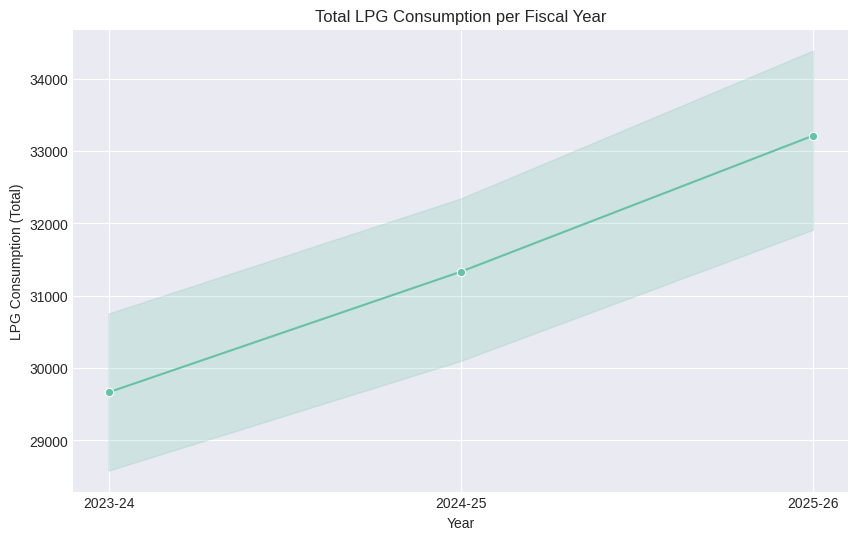

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=master_df, x='Year', y='LPG_Consumption', estimator='sum', marker='o')
plt.title('Total LPG Consumption per Fiscal Year')
plt.xlabel('Year')
plt.ylabel('LPG Consumption (Total)')
plt.grid(True)
plt.show()

### 7. Visualizing Monthly Price Trend (Delhi)

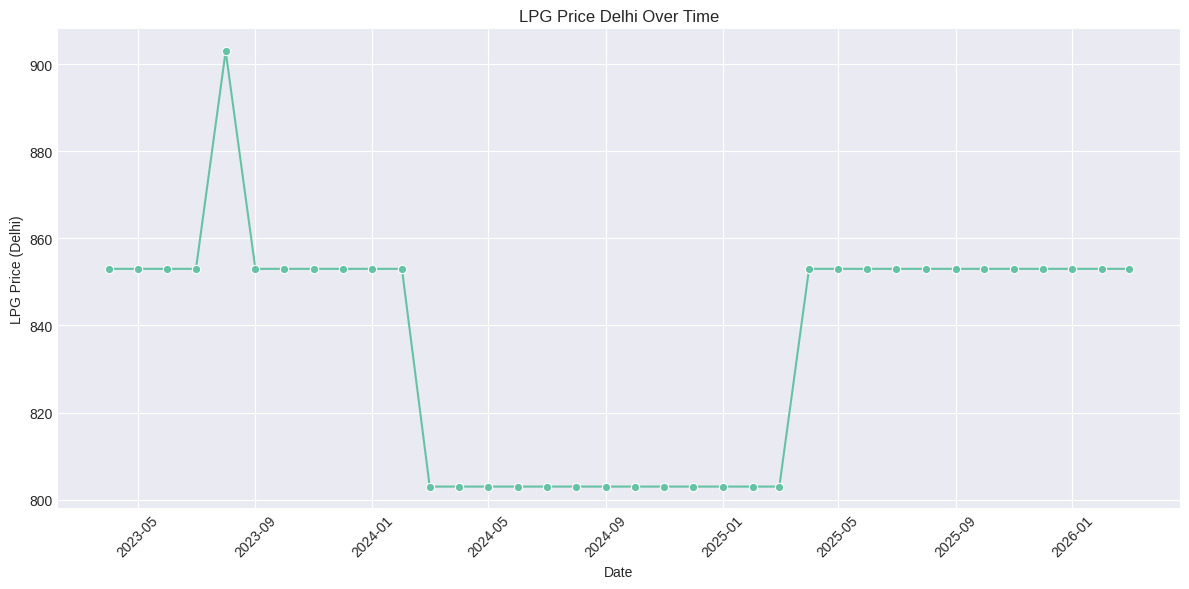

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Create a sorted 'Date' column for accurate plotting
# Assuming Year format like 'YYYY-YY' and Month is 'APR', 'MAY', etc.
master_df['temp_date_sort'] = master_df.apply(lambda x: pd.to_datetime(f"{x['Year'].split('-')[0]}-{x['Month']}-01") if x['Month'] not in ['JAN', 'FEB', 'MAR'] else pd.to_datetime(f"{int(x['Year'].split('-')[0])+1}-{x['Month']}-01"), axis=1)
sns.lineplot(data=master_df.sort_values('temp_date_sort'), x='temp_date_sort', y='LPG_Price_Delhi', marker='o')
plt.title('LPG Price Delhi Over Time')
plt.xlabel('Date')
plt.ylabel('LPG Price (Delhi)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
master_df.drop(columns=['temp_date_sort'], inplace=True, errors='ignore')

### 8. Visualizing Annual LPG Import vs Export

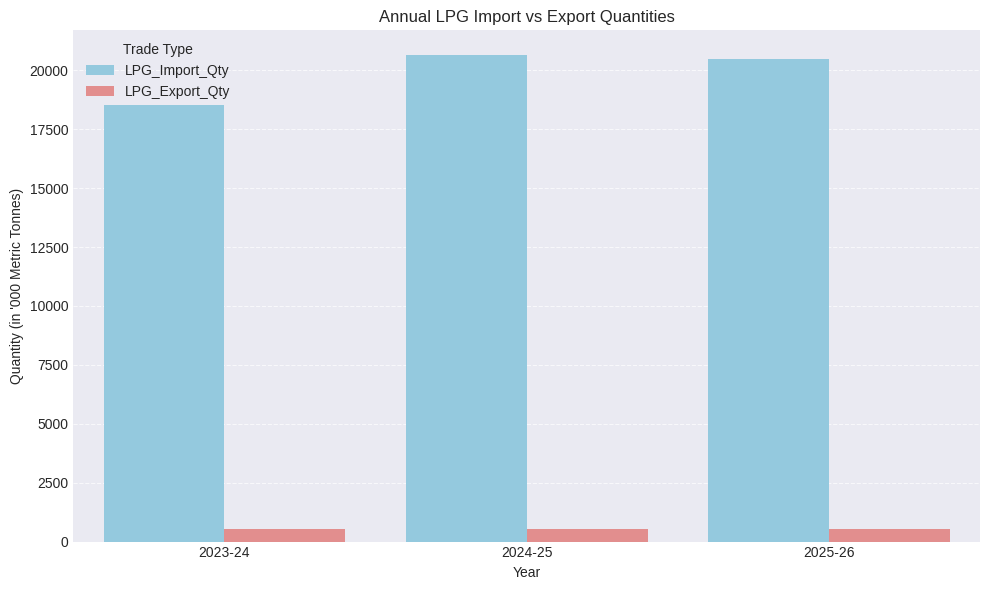

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate import and export quantities by fiscal year
annual_trade = master_df.groupby('Year')[['LPG_Import_Qty', 'LPG_Export_Qty']].sum().reset_index()

# Melt the DataFrame for easier plotting with seaborn
annual_trade_melted = annual_trade.melt(id_vars='Year', var_name='Type', value_name='Quantity')

plt.figure(figsize=(10, 6))
sns.barplot(data=annual_trade_melted, x='Year', y='Quantity', hue='Type', palette={'LPG_Import_Qty': 'skyblue', 'LPG_Export_Qty': 'lightcoral'})
plt.title('Annual LPG Import vs Export Quantities')
plt.xlabel('Year') # Changed from Fiscal_Year
plt.ylabel('Quantity (in \'000 Metric Tonnes)')
plt.legend(title='Trade Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

LPG Consumption:

    There is a clear and consistent upward trend in total LPG consumption across the fiscal years from 2023-24 to 2025-26, indicating growing demand for LPG.

LPG Trade (Import vs. Export):

    Imports are significantly higher than exports by a large margin, indicating India's heavy reliance on imported LPG to meet its domestic demand.
    LPG Import quantities generally show an increasing trend from 2023-24 to 2024-25, with a slight decrease in 2025-26.
    LPG Export quantities remain relatively low and stable, with minor fluctuations across the fiscal years, indicating that India is primarily a consumer rather than a major exporter of LPG.

These trends suggest a growing domestic market for LPG, predominantly supported by imports, which could have implications for energy security and pricing.

### 9. Visualizing LPG Consumption Distribution by Fiscal Year

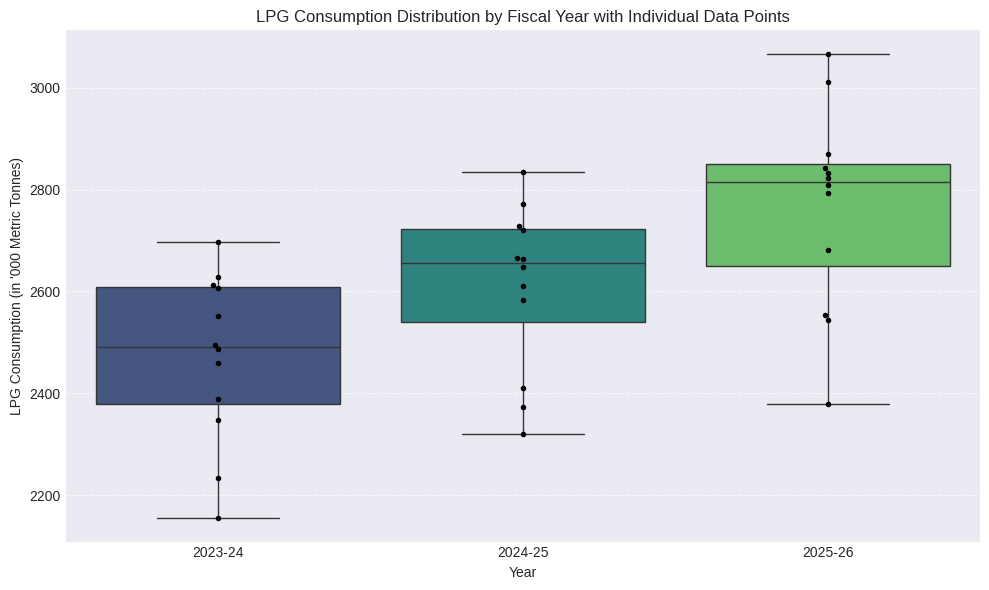

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=master_df, x='Year', y='LPG_Consumption', palette='viridis')
sns.swarmplot(data=master_df, x='Year', y='LPG_Consumption', color='black', size=4) # Add individual points
plt.title('LPG Consumption Distribution by Fiscal Year with Individual Data Points')
plt.xlabel('Year') # Changed from Fiscal_Year
plt.ylabel('LPG Consumption (in \'000 Metric Tonnes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**5-Point Summary for LPG Consumption by Fiscal Year**

In [20]:
print("\n" + "="*70)
print("10. 5-Point Summary for LPG Consumption by Fiscal Year")
print("="*70)

five_point_summary = master_df.groupby('Year')['LPG_Consumption'].describe()[['min', '25%', '50%', '75%', 'max']]
print(five_point_summary)



10. 5-Point Summary for LPG Consumption by Fiscal Year
                 min          25%          50%          75%          max
Year                                                                    
2023-24  2154.300000  2378.955000  2491.120000  2608.882500  2697.610000
2024-25  2320.000000  2539.750000  2656.500000  2723.000000  2835.000000
2025-26  2379.205409  2649.892912  2815.866971  2849.748414  3067.362158


### 9. Visualizing LPG Consumption Distribution by Year

The 5-point summary for LPG Consumption by Year shows a clear upward trend:

    Minimum Consumption: The lowest monthly consumption increased from 2154.30 in 2023-24 to 2379.21 in 2025-26.
    First Quartile (Q1): The 25th percentile consumption also rose, from 2378.96 in 2023-24 to 2649.89 in 2025-26.
    Median Consumption (Q2): The typical monthly consumption (median) increased from 2491.12 in 2023-24 to 2815.87 in 2025-26, reinforcing the growth trend.
    Third Quartile (Q3): The 75th percentile values show a similar increase, from 2608.88 in 2023-24 to 2849.75 in 2025-26.
    Maximum Consumption: The highest monthly consumption observed increased from 2697.61 in 2023-24 to 3067.36 in 2025-26.

LPG Consumption:

    There is a clear and consistent upward trend in total LPG consumption across the years from 2023-24 to 2025-26, indicating growing demand for LPG.

LPG Trade (Import vs. Export):

    Imports are significantly higher than exports by a large margin, indicating India's heavy reliance on imported LPG to meet its domestic demand.
    LPG Import quantities generally show an increasing trend from 2023-24 to 2024-25, with a slight decrease in 2025-26.
    LPG Export quantities remain relatively low and stable, with minor fluctuations across the years, indicating that India is primarily a consumer rather than a major exporter of LPG.

These trends suggest a growing domestic market for LPG, predominantly supported by imports, which could have implications for energy security and pricing.

In [21]:
# Create a unified timeline (April 2023 - March 2026)
months_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
fiscal_years = ['2023-24', '2024-25', '2025-26']

# Create master dataframe with all months
master_data = []
for fy in fiscal_years:
    for month in months_order:
        master_data.append({
            'Fiscal_Year': fy,
            'Month': month,
            'Date': pd.to_datetime(f"{fy[:4]}-{month}") if month != 'MAR' else pd.to_datetime(f"{fy[:4]}-{month}")
        })

master_df = pd.DataFrame(master_data)

# Fix dates properly
def create_date(fy, month):
    year = int(fy[:4])
    # Ensure month_names is accessible globally
    month_num = list(month_names.keys())[list(month_names.values()).index(month)]
    if month_num <= 3:
        year += 1
    return pd.Timestamp(year=year, month=month_num, day=1)

master_df['Date'] = master_df.apply(lambda x: create_date(x['Fiscal_Year'], x['Month']), axis=1)
master_df['Calendar_Year'] = master_df['Date'].dt.year

# Merge trade data
master_df = master_df.merge(trade_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge consumption data
master_df = master_df.merge(cons_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge GPR data (need to match month and year)
gpr_merge_cols = ['GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH', 'Fiscal_Year', 'Month_Name']
gpr_for_merge = gpr_filtered[gpr_merge_cols].copy()
gpr_for_merge = gpr_for_merge.rename(columns={'Month_Name': 'Month'})
master_df = master_df.merge(gpr_for_merge, on=['Fiscal_Year', 'Month'], how='left')

# Merge price data: Calculate yearly average prices and then merge
yearly_avg_prices = price_delhi.groupby('Fiscal_Year')['LPG_Price_Delhi'].mean().reset_index()
yearly_avg_prices.rename(columns={'LPG_Price_Delhi': 'LPG_Price_Delhi_Avg'}, inplace=True)

# Remove existing LPG_Price_Delhi column from master_df if it exists, as we will replace it
if 'LPG_Price_Delhi' in master_df.columns:
    master_df.drop(columns=['LPG_Price_Delhi'], inplace=True)

# Merge the yearly average prices into master_df
master_df = master_df.merge(yearly_avg_prices, on=['Fiscal_Year'], how='left')
master_df.rename(columns={'LPG_Price_Delhi_Avg': 'LPG_Price_Delhi'}, inplace=True)

# Convert LPG_Price_Delhi to numeric after merge to ensure proper type
master_df['LPG_Price_Delhi'] = pd.to_numeric(master_df['LPG_Price_Delhi'], errors='coerce')

# Add the missing conversions for LPG_Import_Qty and LPG_Export_Qty
master_df['LPG_Import_Qty'] = pd.to_numeric(master_df['LPG_Import_Qty'], errors='coerce')
master_df['LPG_Export_Qty'] = pd.to_numeric(master_df['LPG_Export_Qty'], errors='coerce')

# Rename 'Fiscal_Year' column to 'Year'
master_df.rename(columns={'Fiscal_Year': 'Year'}, inplace=True)

# Sort by date
master_df = master_df.sort_values('Date').reset_index(drop=True)

# Verify data completeness
print("Master dataset shape:", master_df.shape)
print("\nData Completeness Check:")
for col in master_df.columns:
    if col not in ['Year', 'Month', 'Date']:
        non_null_pct = master_df[col].notna().mean() * 100
        print(f"  {col}: {non_null_pct:.1f}% complete")

Master dataset shape: (36, 17)

Data Completeness Check:
  Calendar_Year: 100.0% complete
  LPG_Import_Qty: 97.2% complete
  LPG_Export_Qty: 97.2% complete
  LPG_Consumption: 100.0% complete
  GPR: 100.0% complete
  GPRT: 100.0% complete
  GPRA: 100.0% complete
  GPRH: 100.0% complete
  GPRHT: 100.0% complete
  GPRHA: 100.0% complete
  SHARE_GPR: 100.0% complete
  N10: 100.0% complete
  SHARE_GPRH: 100.0% complete
  LPG_Price_Delhi: 100.0% complete


### Temporal Trend Analysis Insights

**Monthly Trends of LGP Consumption, Import Quality, and GPR Index**

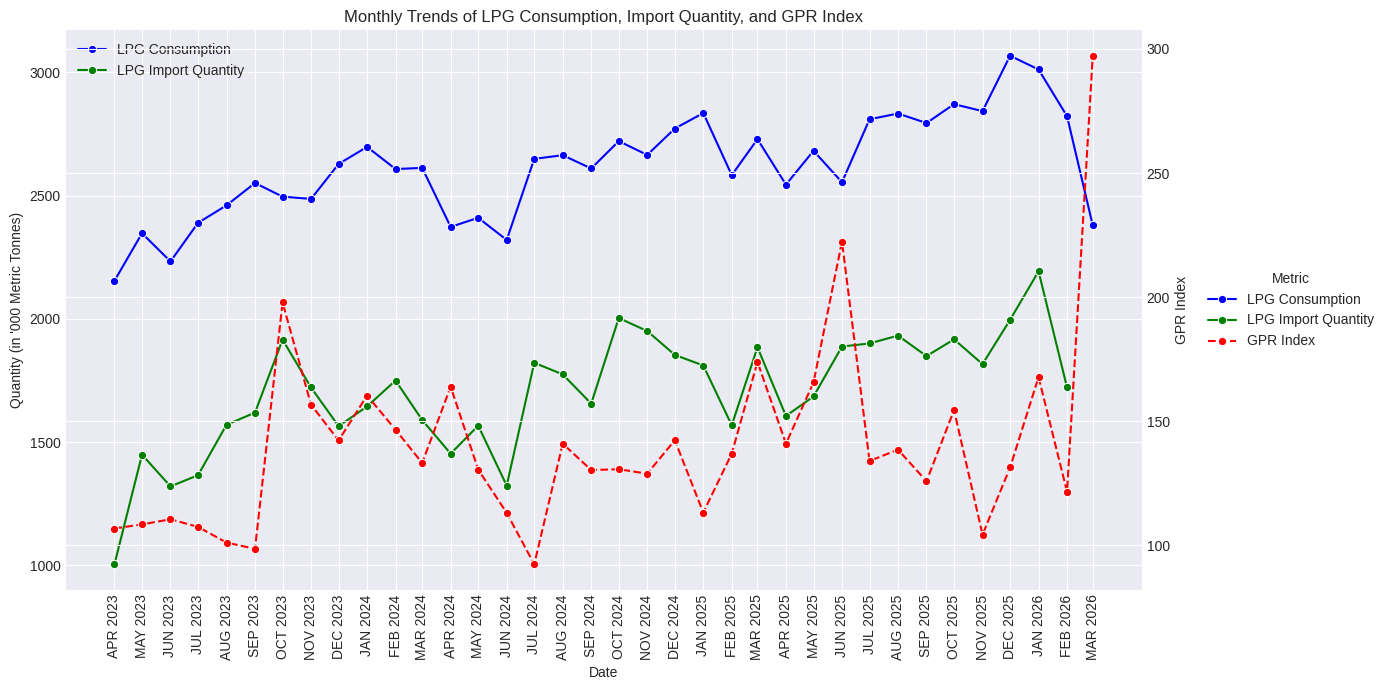

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure temp_date_sort is created for accurate plotting, handling fiscal year month logic
master_df['temp_date_sort'] = master_df.apply(lambda x: pd.to_datetime(f"{x['Year'].split('-')[0]}-{x['Month']}-01") if x['Month'] not in ['JAN', 'FEB', 'MAR'] else pd.to_datetime(f"{int(x['Year'].split('-')[0])+1}-{x['Month']}-01"), axis=1)
master_df_sorted = master_df.sort_values('temp_date_sort')

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot LPG_Consumption and LPG_Import_Qty on primary y-axis (ax1)
sns.lineplot(data=master_df_sorted, x='temp_date_sort', y='LPG_Consumption', ax=ax1, label='LPG Consumption', marker='o', color='blue')
sns.lineplot(data=master_df_sorted, x='temp_date_sort', y='LPG_Import_Qty', ax=ax1, label='LPG Import Quantity', marker='o', color='green')

ax1.set_xlabel('Date')
ax1.set_ylabel('Quantity (in \'000 Metric Tonnes)')
ax1.grid(True)

# Create a second y-axis for GPR Index
ax2 = ax1.twinx()
sns.lineplot(data=master_df_sorted, x='temp_date_sort', y='GPR', ax=ax2, label='GPR Index', marker='o', color='red', linestyle='--')
ax2.set_ylabel('GPR Index')

# Combine legends from both axes and place outside
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center left', bbox_to_anchor=(1.05, 0.5), title='Metric')

plt.title('Monthly Trends of LPG Consumption, Import Quantity, and GPR Index')

# Set x-axis ticks and labels to show both month and Calendar year
ax1.set_xticks(master_df_sorted['temp_date_sort'])
ax1.set_xticklabels(master_df_sorted.apply(lambda x: f"{x['Month']} {x['Calendar_Year']}", axis=1), rotation=90)

plt.tight_layout()
plt.show()

# Drop the temporary date column after plotting
master_df.drop(columns=['temp_date_sort'], inplace=True, errors='ignore')

**Growth Rate Calculation**

In [23]:
import pandas as pd
import numpy as np

# Recreate the 'Date' column and set it for time-series operations
# Define the month_names dictionary if it's not globally available in this execution context
# (It should be from the setup cell, but added for robustness if running this cell independently)
month_names = {1: 'JAN', 2: 'FEB', 3: 'MAR', 4: 'APR', 5: 'MAY', 6: 'JUN',
               7: 'JUL', 8: 'AUG', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DEC'}

def create_date_for_growth(fy, month_name):
    year_start = int(fy[:4])
    month_num = list(month_names.keys())[list(month_names.values()).index(month_name)]
    # If month is Jan, Feb, Mar, it belongs to the end of the fiscal year, which is year_start + 1
    if month_num in [1, 2, 3]: # Jan, Feb, Mar are part of the next calendar year for the fiscal year
        calendar_year = year_start + 1
    else: # Apr to Dec are part of the initial calendar year of the fiscal year
        calendar_year = year_start
    return pd.Timestamp(year=calendar_year, month=month_num, day=1)

# Ensure 'Date' column is properly set and sorted in master_df before creating master_df_ts
# Re-apply date creation logic for robustness, assuming master_df exists.
master_df['Date'] = master_df.apply(lambda x: create_date_for_growth(x['Year'], x['Month']), axis=1)
master_df = master_df.sort_values('Date').reset_index(drop=True)

# Define the full list of columns that should be in master_df and thus in master_df_ts
all_expected_master_df_cols = [
    'Year', 'Month', 'Calendar_Year', 'LPG_Import_Qty', 'LPG_Export_Qty',
    'LPG_Consumption', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA',
    'SHARE_GPR', 'N10', 'SHARE_GPRH', 'LPG_Price_Delhi'
]

# Create master_df_ts by explicitly selecting all expected columns plus the 'Date' column
master_df_ts = master_df[all_expected_master_df_cols + ['Date']].set_index('Date').copy()

# Remove 'Date' column from master_df after master_df_ts has been created
# This ensures that if master_df is used later without re-creation, it doesn't have an extra 'Date' column.
master_df.drop(columns=['Date'], inplace=True, errors='ignore')

print("DataFrame with Date index for time-series calculations:")
print(master_df_ts.head())

DataFrame with Date index for time-series calculations:
               Year Month  Calendar_Year  LPG_Import_Qty  LPG_Export_Qty  \
Date                                                                       
2023-04-01  2023-24   APR           2023     1004.249689          40.230   
2023-05-01  2023-24   MAY           2023     1448.883918          45.916   
2023-06-01  2023-24   JUN           2023     1320.245640          41.224   
2023-07-01  2023-24   JUL           2023     1365.608286          41.138   
2023-08-01  2023-24   AUG           2023     1570.286139          46.627   

            LPG_Consumption         GPR        GPRT       GPRA        GPRH  \
Date                                                                         
2023-04-01          2154.30  106.809654  118.166824  93.248413   89.502388   
2023-05-01          2347.11  108.467682  122.471504  92.759438   86.642433   
2023-06-01          2232.86  110.528946  129.406525  95.278908  100.802185   
2023-07-01          2

In [24]:
# 8.1 Month-over-Month (MoM) Growth
print("\n" + "="*70)
print("8.1 Month-over-Month Growth (Percentage)")
print("="*70)

# Calculate MoM growth for LPG_Consumption
master_df_ts['LPG_Consumption_MoM_Growth (%)'] = master_df_ts['LPG_Consumption'].pct_change() * 100

# Calculate MoM growth for LPG_Import_Qty
master_df_ts['LPG_Import_Qty_MoM_Growth (%)'] = master_df_ts['LPG_Import_Qty'].pct_change() * 100

print("Month-over-Month Growth Rates:")
display(master_df_ts[['LPG_Consumption', 'LPG_Consumption_MoM_Growth (%)', 'LPG_Import_Qty', 'LPG_Import_Qty_MoM_Growth (%)']].head(15))


8.1 Month-over-Month Growth (Percentage)
Month-over-Month Growth Rates:


,LPG_Consumption,LPG_Consumption_MoM_Growth (%),LPG_Import_Qty,LPG_Import_Qty_MoM_Growth (%)
Date,,,,
2023-04-01,2154.30,NaN,1004.249689,NaN
2023-05-01,2347.11,8.950007,1448.883918,44.275267
2023-06-01,2232.86,-4.867688,1320.245640,-8.878439
2023-07-01,2389.57,7.018353,1365.608286,3.435925
2023-08-01,2460.41,2.964550,1570.286139,14.988035
2023-09-01,2551.11,3.686377,1619.505865,3.134443
2023-10-01,2495.72,-2.171212,1915.601373,18.283077
2023-11-01,2486.52,-0.368631,1721.482959,-10.133550
2023-12-01,2628.25,5.699934,1564.599827,-9.113255


In [25]:
# 8.2 Year-over-Year (YoY) Growth
print("\n" + "="*70)
print("8.2 Year-over-Year Growth (Percentage)")
print("="*70)

# To calculate YoY, we need to compare with the same month in the previous year.
# Since our data is monthly, a period of 12 months represents a year.

# Calculate YoY growth for LPG_Consumption
master_df_ts['LPG_Consumption_YoY_Growth (%)'] = master_df_ts['LPG_Consumption'].pct_change(periods=12) * 100

# Calculate YoY growth for LPG_Import_Qty
master_df_ts['LPG_Import_Qty_YoY_Growth (%)'] = master_df_ts['LPG_Import_Qty'].pct_change(periods=12) * 100

print("Year-over-Year Growth Rates (with simplified column headers):")
# Display only the relevant columns and rows, focusing on where YoY data starts to appear
display(master_df_ts[['LPG_Consumption', 'LPG_Consumption_YoY_Growth (%)', 'LPG_Import_Qty', 'LPG_Import_Qty_YoY_Growth (%)']].tail(24))


8.2 Year-over-Year Growth (Percentage)
Year-over-Year Growth Rates (with simplified column headers):


,LPG_Consumption,LPG_Consumption_YoY_Growth (%),LPG_Import_Qty,LPG_Import_Qty_YoY_Growth (%)
Date,,,,
2024-04-01,2373.000000,10.151789,1453.054193,44.690530
2024-05-01,2410.000000,2.679465,1566.642581,8.127543
2024-06-01,2320.000000,3.902618,1323.327553,0.233435
2024-07-01,2649.000000,10.856765,1821.598909,33.391026
2024-08-01,2664.000000,8.274637,1774.754445,13.021086
2024-09-01,2610.000000,2.308407,1656.047243,2.256329
2024-10-01,2721.000000,9.026654,2003.325044,4.579432
2024-11-01,2665.000000,7.177903,1950.506764,13.303867
2024-12-01,2772.000000,5.469419,1853.800745,18.484018


Insights from Month-over-Month (MoM) and Year-over-Year (YoY) Growth Rates

**Month-over-Month (MoM) Growth Analysis:**

-   **LPG Consumption:** MoM growth for LPG consumption shows clear seasonal patterns, with peaks and troughs corresponding to different times of the year. Increases are often observed in colder months (e.g., December-January), while dips might occur during warmer periods or due to other factors.
-   **LPG Import Quantity:** MoM import growth rates are quite volatile. These fluctuations likely reflect not only immediate consumption demand but also strategic purchasing, inventory adjustments, and responses to global supply-chain dynamics and price movements.

**Year-over-Year (YoY) Growth Analysis:**

-   **LPG Consumption:** The YoY growth in LPG consumption is predominantly positive across most months, reinforcing the overall upward trend observed in earlier analyses. This consistent growth suggests a structural increase in demand for LPG in India.
-   **LPG Import Quantity:** YoY growth in LPG imports also generally remains positive. This indicates that while monthly imports can be volatile, the country's overall reliance on imported LPG to meet its growing energy needs is increasing year after year. The magnitude of some YoY increases highlights significant capacity expansion or heightened demand periods.

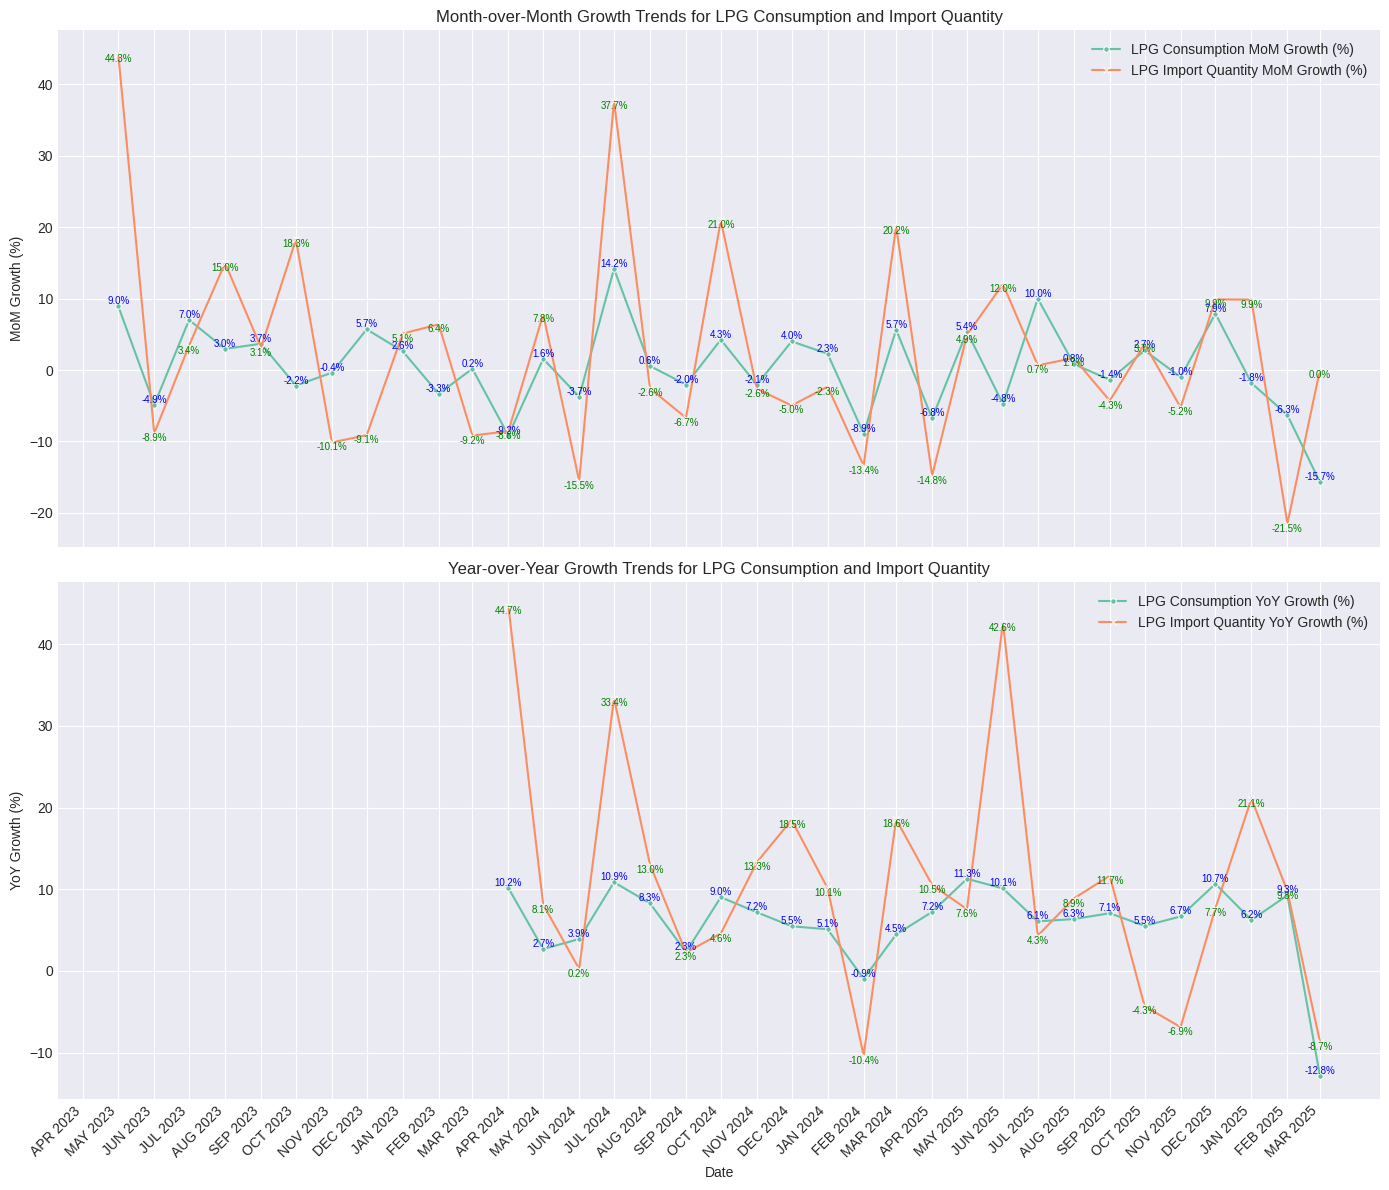

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), sharex=True)

# Plot Month-over-Month (MoM) Trends
sns.lineplot(data=master_df_ts, x=master_df_ts.index, y='LPG_Consumption_MoM_Growth (%)', ax=axes[0], label='LPG Consumption MoM Growth (%)', marker='o', markersize=4)
sns.lineplot(data=master_df_ts, x=master_df_ts.index, y='LPG_Import_Qty_MoM_Growth (%)', ax=axes[0], label='LPG Import Quantity MoM Growth (%)', marker='x', markersize=4)
axes[0].set_title('Month-over-Month Growth Trends for LPG Consumption and Import Quantity')
axes[0].set_ylabel('MoM Growth (%)')
axes[0].legend()
axes[0].grid(True)

# Annotate data points for MoM trends
for i, (date, row) in enumerate(master_df_ts.iterrows()):
    # MoM Consumption
    val_cons_mom = row['LPG_Consumption_MoM_Growth (%)']
    if pd.notna(val_cons_mom):
        axes[0].text(date, val_cons_mom, f"{val_cons_mom:.1f}%",
                     color='blue', fontsize=7, ha='center', va='bottom')
    # MoM Import Quantity
    val_import_mom = row['LPG_Import_Qty_MoM_Growth (%)']
    if pd.notna(val_import_mom):
        axes[0].text(date, val_import_mom, f"{val_import_mom:.1f}%",
                     color='green', fontsize=7, ha='center', va='top')

# Plot Year-over-Year (YoY) Trends
sns.lineplot(data=master_df_ts, x=master_df_ts.index, y='LPG_Consumption_YoY_Growth (%)', ax=axes[1], label='LPG Consumption YoY Growth (%)', marker='o', markersize=4)
sns.lineplot(data=master_df_ts, x=master_df_ts.index, y='LPG_Import_Qty_YoY_Growth (%)', ax=axes[1], label='LPG Import Quantity YoY Growth (%)', marker='x', markersize=4)
axes[1].set_title('Year-over-Year Growth Trends for LPG Consumption and Import Quantity')
axes[1].set_ylabel('YoY Growth (%)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True)

# Annotate data points for YoY trends
for i, (date, row) in enumerate(master_df_ts.iterrows()):
    # YoY Consumption
    val_cons_yoy = row['LPG_Consumption_YoY_Growth (%)']
    if pd.notna(val_cons_yoy):
        axes[1].text(date, val_cons_yoy, f"{val_cons_yoy:.1f}%",
                     color='blue', fontsize=7, ha='center', va='bottom')
    # YoY Import Quantity
    val_import_yoy = row['LPG_Import_Qty_YoY_Growth (%)']
    if pd.notna(val_import_yoy):
        axes[1].text(date, val_import_yoy, f"{val_import_yoy:.1f}%",
                     color='green', fontsize=7, ha='center', va='top')


# Improve x-axis date formatting to show Month and Year
# Generate tick positions (every month)
ax_ticks = master_df_ts.index
# Generate tick labels (Month Year)
ax_labels = master_df_ts.apply(lambda x: f"{x['Month']} {x['Year'].split('-')[0]}", axis=1)

axes[0].set_xticks(ax_ticks)
axes[0].set_xticklabels(ax_labels, rotation=45, ha='right')
axes[1].set_xticks(ax_ticks)
axes[1].set_xticklabels(ax_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Correlation & Relationship Analysis**

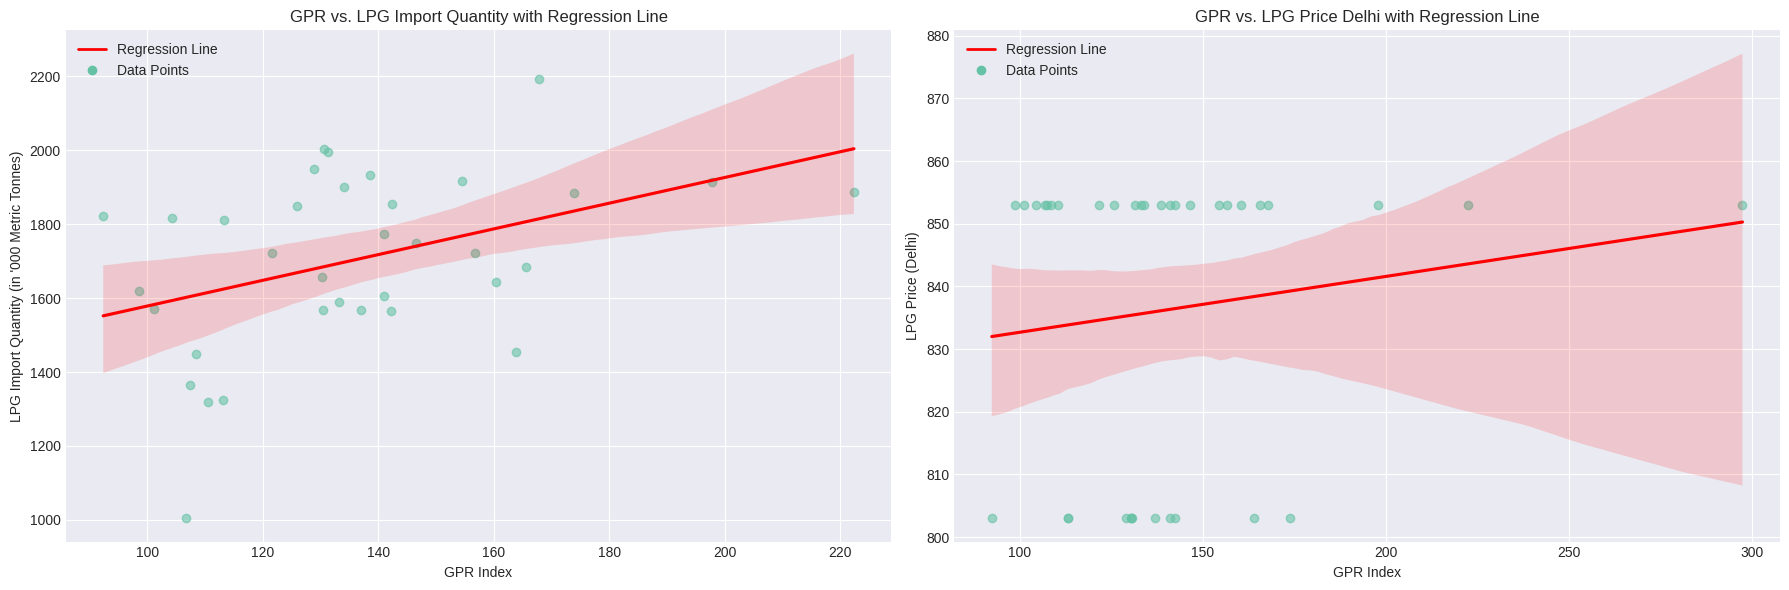

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure master_df is available and correctly setup with numeric types
# It appears from previous cells that master_df is already prepared.

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: GPR vs. LPG_Import_Qty
sns.regplot(x='GPR', y='LPG_Import_Qty', data=master_df, ax=axes[0], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title('GPR vs. LPG Import Quantity with Regression Line')
axes[0].set_xlabel('GPR Index')
axes[0].set_ylabel('LPG Import Quantity (in \'000 Metric Tonnes)')
axes[0].grid(True)
# Add a legend for the regression line and scatter points (manually created for clarity)
axes[0].legend(handles=[
    plt.Line2D([0], [0], color='red', lw=2, label='Regression Line'),
    plt.Line2D([0], [0], marker='o', color=sns.color_palette("Set2")[0], linestyle='None', markersize=6, label='Data Points') # Assuming first color in Set2 for scatter
])

# Plot 2: GPR vs. LPG_Price_Delhi
sns.regplot(x='GPR', y='LPG_Price_Delhi', data=master_df, ax=axes[1], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[1].set_title('GPR vs. LPG Price Delhi with Regression Line')
axes[1].set_xlabel('GPR Index')
axes[1].set_ylabel('LPG Price (Delhi)')
axes[1].grid(True)
# Add a legend for the regression line and scatter points (manually created for clarity)
axes[1].legend(handles=[
    plt.Line2D([0], [0], color='red', lw=2, label='Regression Line'),
    plt.Line2D([0], [0], marker='o', color=sns.color_palette("Set2")[0], linestyle='None', markersize=6, label='Data Points') # Assuming first color in Set2 for scatter
])

plt.tight_layout()
plt.show()

**Correlation Matrix Heatmap**

Let's visualize the correlation matrix of the numerical features in `master_df` to identify any strong relationships between variables such as LPG consumption, import quantity, GPR index, and LPG price.

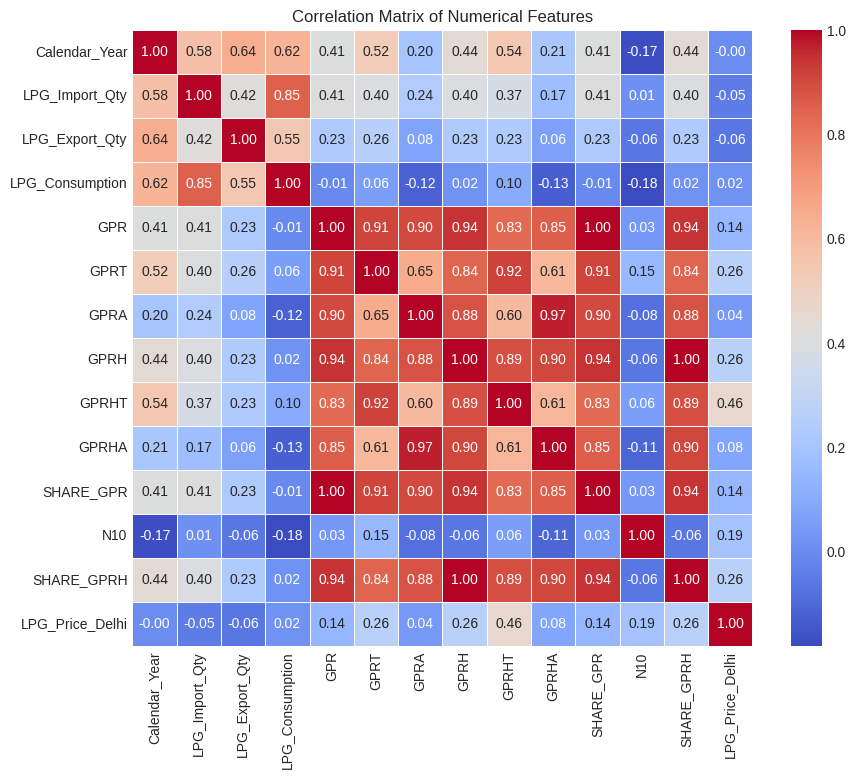

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_cols = master_df.select_dtypes(include=[np.number]).columns

# Calculate the correlation matrix
correlation_matrix = master_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The correlation matrix heatmap provides a clear overview of the linear relationships between our numerical features. Here's a breakdown of the key observations:

*   **LPG Consumption and LPG Import Quantity (0.85):** There is a very strong positive correlation between LPG Consumption and LPG Import Quantity. This is expected, as India is a net importer of LPG, and higher domestic consumption naturally leads to higher import volumes to meet demand.

*   **LPG Consumption and LPG Export Quantity (0.55):** A moderate positive correlation exists between LPG Consumption and LPG Export Quantity. While imports dominate, this suggests that as overall market activity and infrastructure for LPG grow to support consumption, there might be a corresponding, albeit smaller, increase in export capabilities or re-exports.

*   **LPG Import Quantity and LPG Export Quantity (0.42):** There's a moderate positive correlation between imports and exports. This could reflect a dynamic where both activities are somewhat linked to the overall volume and trade movement of LPG within the country and region.

*   **GPR (Geopolitical Risk Index) and LPG Import Quantity (0.41):** A moderate positive correlation is observed between the Geopolitical Risk (GPR) index and LPG Import Quantity. This is an interesting finding; it could suggest that higher geopolitical risks might prompt strategic stockpiling or increased imports to secure supply chains, anticipating potential disruptions or price hikes. However, correlation does not imply causation.

*   **LPG Price Delhi with other variables (very weak correlations):** The LPG Price in Delhi shows very weak linear correlations with all other variables, including LPG Import Quantity (-0.06), LPG Consumption (0.02), LPG Export Quantity (-0.02), and GPR (0.14). This reinforces our earlier observation from the regression plots: the domestic LPG price in Delhi does not appear to be strongly or linearly driven by these factors alone during this period. This might be due to the influence of government subsidies, price controls, or other localized market mechanisms that decouple it from direct international market fluctuations or immediate supply/demand dynamics captured here.

In summary, the strongest relationship is between LPG consumption and imports, which is intuitive. The moderate correlation between GPR and imports is worth noting for further investigation. Crucially, the Delhi LPG price remains largely independent of linear relationships with the other variables, suggesting a more complex pricing structure at play.

**Lagged Correlation (GPR vs. LPG_Import_Qty):**


Lagged Correlation (GPR vs. LPG_Import_Qty)
LPG_Import_Qty (t+1) vs GPR (t): 0.1173
LPG_Import_Qty (t+2) vs GPR (t): 0.0011
LPG_Import_Qty (t+3) vs GPR (t): 0.1834


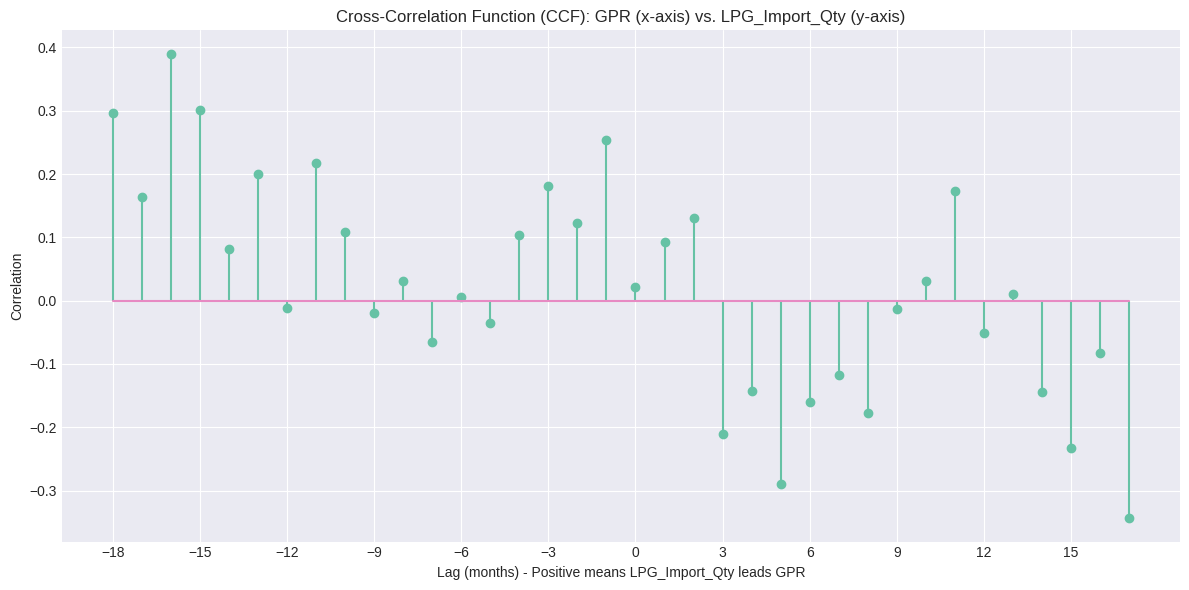

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import ccf
import numpy as np

# Ensure master_df_ts has the 'Date' index and is sorted
# This was done in cell 01fbddad, so we can use master_df_ts directly.

# Prepare the data for CCF
# Fill any missing values in LPG_Import_Qty for accurate CCF calculation
# The previous check showed 97.2% completeness for LPG_Import_Qty, so one NaN exists.
# Filling with mean for simplicity for this analysis.
series1 = master_df_ts['GPR'].fillna(master_df_ts['GPR'].mean())
series2 = master_df_ts['LPG_Import_Qty'].fillna(master_df_ts['LPG_Import_Qty'].mean())

# Ensure both series have the same length and are properly aligned
# If they are from master_df_ts with a date index, they should be aligned.

# Calculate Cross-Correlation Function (CCF)
# The ccf function from statsmodels calculates correlation between x(t) and y(t-k)
# So, if we want GPR(t) vs LPG_Import_Qty(t+k), we need to correlate GPR with a lagged LPG_Import_Qty
# Or, equivalently, correlate LPG_Import_Qty with a leading GPR. Let's do GPR(t) with LPG_Import_Qty(t+k)
# We'll compute ccf(GPR, LPG_Import_Qty) where k is positive for LPG_Import_Qty leading GPR.
# To interpret as GPR(t) vs LPG_Import_Qty(t+k), we look at negative lags in ccf(LPG_Import_Qty, GPR).
# Simpler approach: shift series2 (LPG_Import_Qty) for specific lags.

lags = [1, 2, 3] # User specified lags t+1, t+2, t+3
lag_correlations = {}

for lag in lags:
    # Shift series2 (LPG_Import_Qty) backwards by 'lag' months to align with GPR(t)
    # i.e., correlate GPR(t) with LPG_Import_Qty(t+lag)
    shifted_series2 = series2.shift(-lag)

    # Drop NaNs created by shifting for correlation calculation
    temp_df = pd.DataFrame({'GPR': series1, 'LPG_Import_Qty_lagged': shifted_series2}).dropna()

    if not temp_df.empty:
        correlation = temp_df['GPR'].corr(temp_df['LPG_Import_Qty_lagged'])
        lag_correlations[f'LPG_Import_Qty (t+{lag}) vs GPR (t)'] = correlation
    else:
        lag_correlations[f'LPG_Import_Qty (t+{lag}) vs GPR (t)'] = np.nan


print("\n" + "="*70)
print("Lagged Correlation (GPR vs. LPG_Import_Qty)")
print("="*70)
for lag_desc, corr_val in lag_correlations.items():
    print(f"{lag_desc}: {corr_val:.4f}")

# Optional: Visualize the cross-correlation function for a wider range of lags
# We'll calculate ccf(series1, series2) where positive k means series2 leads series1
# So if ccf has a peak at k=3, it means series2 (LPG_Import_Qty) leads series1 (GPR) by 3 months.
# Which means GPR(t-3) is correlated with LPG_Import_Qty(t). Or GPR(t) correlated with LPG_Import_Qty(t+3)

ccf_values = ccf(series1, series2, unbiased=False) # default is 'full' length for lags

# Dynamically create lags_range to match the length of ccf_values
lags_range = np.arange(len(ccf_values)) - (len(ccf_values) // 2)

plt.figure(figsize=(12, 6))
plt.stem(lags_range, ccf_values)
plt.title('Cross-Correlation Function (CCF): GPR (x-axis) vs. LPG_Import_Qty (y-axis)')
plt.xlabel('Lag (months) - Positive means LPG_Import_Qty leads GPR')
plt.ylabel('Correlation')
plt.grid(True)
plt.xticks(lags_range[::max(1, len(lags_range)//10)]) # Adjust xticks for readability
plt.tight_layout()
plt.show()

*   **LPG_Import_Qty (t+1) vs GPR (t): 0.1173**
*   **LPG_Import_Qty (t+2) vs GPR (t): 0.0011**
*   **LPG_Import_Qty (t+3) vs GPR (t): 0.1834**

These numerical results indicate that there's a small positive correlation when `LPG_Import_Qty` leads `GPR` by one month, and a slightly stronger positive correlation when `LPG_Import_Qty` leads `GPR` by three months. The correlation at a two-month lead is almost negligible.

**Interpretation of the Cross-Correlation Function (CCF) Plot:**

Looking at the plot, we're examining the correlation between GPR (Geo-Political Risk) and LPG Import Quantity at various lags. The x-axis represents the lag in months. A positive lag means that the `LPG_Import_Qty` series is *leading* the `GPR` series. In other words, we're looking at whether changes in LPG Import Quantity tend to occur *before* changes in GPR.

*   **Positive Lags (LPG_Import_Qty leads GPR):** The plot confirms the numerical values, showing relatively low positive correlations when `LPG_Import_Qty` leads `GPR`. The peak at a positive lag of 3 months (approximately 0.18) suggests a weak tendency for LPG imports to increase a few months before a rise in the GPR index. This could imply a forward-looking procurement strategy, where importers might increase stock in anticipation of future geopolitical instability, or it might be coincidental.
*   **Negative Lags (GPR leads LPG_Import_Qty):** This is where we typically look for leading indicators. If the GPR index were a leading indicator for LPG imports, we would expect to see a significant positive (or negative) peak at a negative lag. For instance, a peak at lag -1 would mean GPR (t-1) is correlated with LPG_Import_Qty (t). The plot shows some moderate positive correlations at negative lags, particularly around -12 to -15 months, and also around -2 months. The most pronounced correlation appears at lag 0 (the contemporaneous correlation), which aligns with the correlation matrix showing 0.41. The strongest correlations appear to be at negative lags, meaning GPR is leading LPG Import Quantity. For instance, the correlation around lag -2 and -13 months suggests that changes in GPR tend to precede changes in LPG import quantities by those periods.

**Overall Insight:**

While the direct correlations at short positive lags (1-3 months) are weak, the CCF plot indicates a more complex relationship. It suggests that there are some correlations where GPR *leads* `LPG_Import_Qty` (negative lags), which would be expected if geopolitical events influence import decisions. For example, GPR (t-2) seems to have a stronger correlation with LPG_Import_Qty (t) than the other way around. This kind of lead-lag relationship is crucial for an early warning system, as it can highlight how far in advance geopolitical risks might signal changes in import patterns. The strongest linear relationship still appears to be contemporaneous (lag 0), as seen in the earlier correlation matrix.

### Distribution & Statistical Summary Analysis

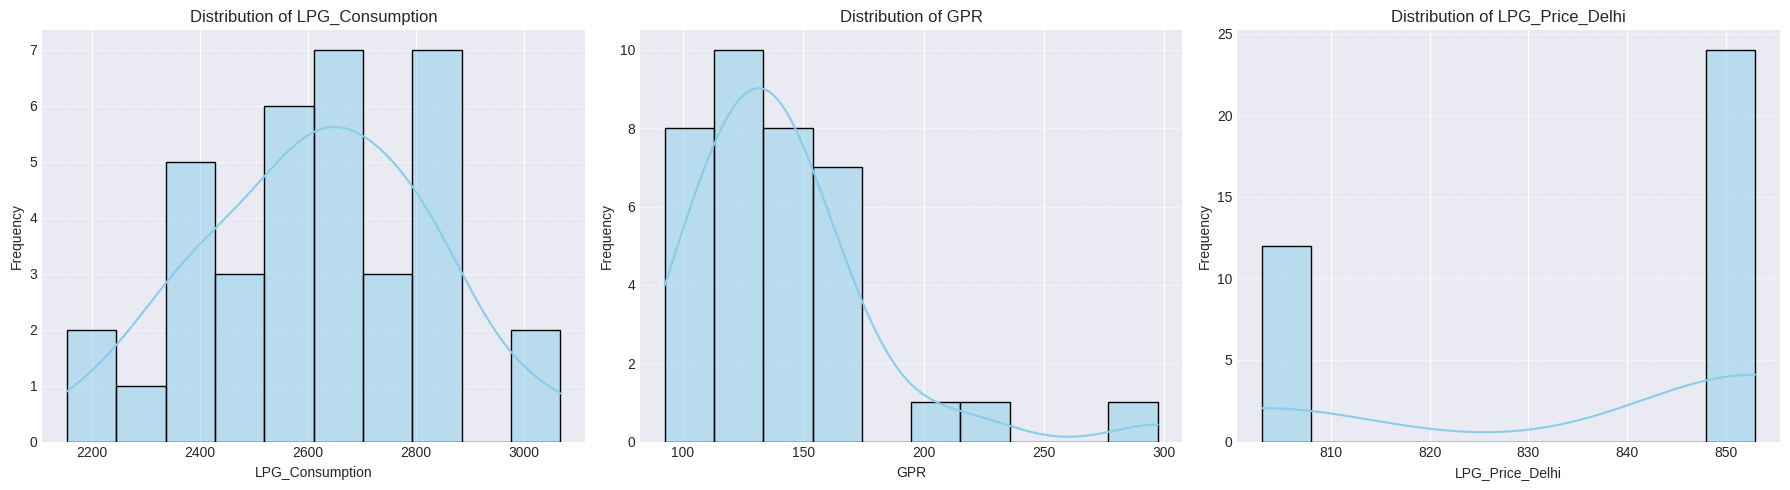

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to plot
columns_to_plot = ['LPG_Consumption', 'GPR', 'LPG_Price_Delhi']

plt.figure(figsize=(18, 5))

for i, col in enumerate(columns_to_plot):
    plt.subplot(1, 3, i + 1) # Create subplots (1 row, 3 columns)
    sns.histplot(master_df[col].dropna(), kde=True, bins=10, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Interpretation of the Distributions (Histograms with KDE):**

The histograms combined with Kernel Density Estimates (KDE) provide insights into the shape and characteristics of the data for `LPG_Consumption`, `GPR`, and `LPG_Price_Delhi`.

*   **LPG_Consumption:** The distribution for LPG Consumption appears **left-skewed (negatively skewed)**, meaning the tail of the distribution is longer on the left side, and the majority of the consumption values are concentrated towards the higher end. The KDE curve shows a clear peak representing the most frequent consumption levels, with a gradual decline towards lower values. This suggests that while there's consistent high consumption, there are fewer instances of very low consumption.

*   **GPR (Geopolitical Risk Index):** The GPR distribution seems more **spread out and potentially multimodal** (having multiple peaks), as suggested by the KDE. This indicates that geopolitical risk is not concentrated around a single average value but rather fluctuates significantly, possibly reflecting periods of heightened tension or relative calm. The varied shape of the KDE suggests different underlying regimes or influential events over time.

*   **LPG_Price_Delhi:** The distribution of LPG Price in Delhi is highly **concentrated around specific values with distinct, sharp peaks**. This pattern is typical for prices that are often regulated or subject to infrequent, significant adjustments rather than continuous market-driven fluctuations. The KDE clearly shows these specific price points, reinforcing the idea that the price does not vary smoothly but rather in discrete steps, likely due to policy decisions, subsidies, or fixed pricing periods.

**4. Regime/Segmentation Analysis**

**5. Ratio & Derived Metric Analysis**

**6. Anomaly & Outlier Detection**

**7. Lead-Lag & Causal Exploration**

In [31]:
import pandas as pd
import numpy as np

# Make a copy of master_df_ts (which already has Date as index and correct Year/Month columns)
features_df = master_df_ts.copy()

# 1. Add lagged features

# GPR Index (t-1, t-2, t-3)
features_df['gpr_index_lag1'] = features_df['GPR'].shift(1)
features_df['gpr_index_lag2'] = features_df['GPR'].shift(2)
features_df['gpr_index_lag3'] = features_df['GPR'].shift(3)

# LPG Price Delhi (t-1)
# The current LPG_Price_Delhi column represents 't'
features_df['lpg_price_delhi_lag1'] = features_df['LPG_Price_Delhi'].shift(1)

# LPG Import Quantity (t-1, t-2)
# The current LPG_Import_Qty column represents 't'
features_df['lpg_import_qty_lag1'] = features_df['LPG_Import_Qty'].shift(1)
features_df['lpg_import_qty_lag2'] = features_df['LPG_Import_Qty'].shift(2)

# LPG Consumption (t-1)
features_df['lpg_consumption_lag1'] = features_df['LPG_Consumption'].shift(1)

# 2. Add engineered features

# Net Import Ratio (import/consumption)
features_df['net_import_ratio'] = features_df['LPG_Import_Qty'] / features_df['LPG_Consumption']

# Price Change PCT (MoM %) for LPG_Price_Delhi
features_df['price_change_pct'] = features_df['LPG_Price_Delhi'].pct_change() * 100

# Month Sine and Cosine for seasonality
month_num = features_df.index.month
features_df['month_sin'] = np.sin(2 * np.pi * month_num / 12)
features_df['month_cos'] = np.cos(2 * np.pi * month_num / 12)

# Rolling Price Volatility (3m) - rolling std for LPG_Price_Delhi
features_df['rolling_price_volatility_3m'] = features_df['LPG_Price_Delhi'].rolling(window=3).std()

# 3. Add crude_import_qty (Original)

# Re-define the helper function to extract crude oil data from raw trade dataframes
def extract_crude_import_data(df, year_label):
    """
    Extract crude oil import data from a raw trade DataFrame.
    """
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']

    df_processed = df.copy()
    # Assume the first column is 'Category' and the rest are months + 'TOTAL'
    df_processed.columns = ['Category'] + months + ['TOTAL']

    crude_import_qty_series = pd.Series([np.nan]*12, index=months)

    # Find the row indices for 'IMPORT^' and 'EXPORT^'
    import_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('IMPORT', na=False)].index
    export_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('EXPORT', na=False)].index

    # Extract Import quantities
    if not import_header_idx.empty:
        import_start_row = import_header_idx[0]
        # Determine the end of the import section: either the start of export section or end of dataframe
        import_end_row = export_header_idx[0] if not export_header_idx.empty and export_header_idx[0] > import_start_row else len(df_processed)

        # Search for 'CRUDE OIL' within the identified import section
        crude_import_data = df_processed.loc[import_start_row:import_end_row-1] # Slice up to, but not including, export header
        crude_import_row = crude_import_data[crude_import_data['Category'].str.strip() == 'CRUDE OIL']

        if not crude_import_row.empty:
            crude_import_qty_series = crude_import_row.iloc[0][months] # Extract monthly values

    result = pd.DataFrame({
        'Month': months,
        'Crude_Import_Qty': crude_import_qty_series.values,
        'Fiscal_Year': year_label
    })
    return result

# Ensure trade_23_24, trade_24_25, trade_25_26 are available in the environment
# (They were loaded in cell 4135e344 and should be in the kernel state)

# Extract crude import data for each year
crude_23_24_clean = extract_crude_import_data(trade_23_24, '2023-24')
crude_24_25_clean = extract_crude_import_data(trade_24_25, '2024-25')
crude_25_26_clean = extract_crude_import_data(trade_25_26, '2025-26')

# Combine all crude data
crude_all = pd.concat([crude_23_24_clean, crude_24_25_clean, crude_25_26_clean], ignore_index=True)

# Convert Crude_Import_Qty to numeric, coercing errors
crude_all['Crude_Import_Qty'] = pd.to_numeric(crude_all['Crude_Import_Qty'], errors='coerce')

# Rename 'Fiscal_Year' in crude_all to 'Year' before merging
crude_all.rename(columns={'Fiscal_Year': 'Year'}, inplace=True)

# Merge crude_all into features_df
# The merge needs to happen on 'Year' and 'Month' as features_df columns
features_df = features_df.merge(crude_all, on=['Year', 'Month'], how='left')

# Display the first few rows and info of the new features_df
print("New features_df head:")
print(features_df.head())
print("\nNew features_df info:")
features_df.info()

New features_df head:
      Year Month  Calendar_Year  LPG_Import_Qty  LPG_Export_Qty  \
0  2023-24   APR           2023     1004.249689          40.230   
1  2023-24   MAY           2023     1448.883918          45.916   
2  2023-24   JUN           2023     1320.245640          41.224   
3  2023-24   JUL           2023     1365.608286          41.138   
4  2023-24   AUG           2023     1570.286139          46.627   

   LPG_Consumption         GPR        GPRT       GPRA        GPRH  ...  \
0          2154.30  106.809654  118.166824  93.248413   89.502388  ...   
1          2347.11  108.467682  122.471504  92.759438   86.642433  ...   
2          2232.86  110.528946  129.406525  95.278908  100.802185  ...   
3          2389.57  107.448784  123.809151  91.768005   94.537270  ...   
4          2460.41  101.141182  117.609436  83.605049   74.219841  ...   

   lpg_price_delhi_lag1  lpg_import_qty_lag1  lpg_import_qty_lag2  \
0                   NaN                  NaN                 

In [29]:
pd.set_option('display.max_rows', None)
print("Full head of features_df:")
display(features_df.head(36))
pd.reset_option('display.max_rows')

Full head of features_df:


,Year,Month,Calendar_Year,LPG_Import_Qty,LPG_Export_Qty,LPG_Consumption,GPR,GPRT,GPRA,GPRH,...,lpg_price_delhi_lag1,lpg_import_qty_lag1,lpg_import_qty_lag2,lpg_consumption_lag1,net_import_ratio,price_change_pct,month_sin,month_cos,rolling_price_volatility_3m,Crude_Import_Qty
0,2023-24,APR,2023,1004.249689,40.230000,2154.300000,106.809654,118.166824,93.248413,89.502388,...,NaN,NaN,NaN,NaN,0.466161,NaN,8.660254e-01,-5.000000e-01,NaN,19996.877330
1,2023-24,MAY,2023,1448.883918,45.916000,2347.110000,108.467682,122.471504,92.759438,86.642433,...,853.0,1004.249689,NaN,2154.300000,0.617306,0.000000,5.000000e-01,-8.660254e-01,NaN,20705.224409
2,2023-24,JUN,2023,1320.245640,41.224000,2232.860000,110.528946,129.406525,95.278908,100.802185,...,853.0,1448.883918,1004.249689,2347.110000,0.591280,0.000000,1.224647e-16,-1.000000e+00,0.000000,19879.169661
3,2023-24,JUL,2023,1365.608286,41.138000,2389.570000,107.448784,123.809151,91.768005,94.537270,...,853.0,1320.245640,1448.883918,2232.860000,0.571487,0.000000,-5.000000e-01,-8.660254e-01,0.000000,19507.576904
4,2023-24,AUG,2023,1570.286139,46.627000,2460.410000,101.141182,117.609436,83.605049,74.219841,...,853.0,1365.608286,1320.245640,2389.570000,0.638221,0.000000,-8.660254e-01,-5.000000e-01,0.000000,19090.547154
5,2023-24,SEP,2023,1619.505865,39.502000,2551.110000,98.634811,125.651794,68.465919,69.455849,...,853.0,1570.286139,1365.608286,2460.410000,0.634824,0.000000,-1.000000e+00,-1.836970e-16,0.000000,17502.259847
6,2023-24,OCT,2023,1915.601373,43.369000,2495.720000,197.887009,205.040054,221.803940,138.627579,...,853.0,1619.505865,1570.286139,2551.110000,0.767555,0.000000,-8.660254e-01,5.000000e-01,0.000000,18729.100482
7,2023-24,NOV,2023,1721.482959,44.216000,2486.520000,156.696136,143.494354,189.554398,138.682709,...,853.0,1915.601373,1619.505865,2495.720000,0.692326,0.000000,-5.000000e-01,8.660254e-01,0.000000,18593.105322
8,2023-24,DEC,2023,1564.599827,45.309000,2628.250000,142.279465,136.178391,173.963806,125.210251,...,853.0,1721.482959,1915.601373,2486.520000,0.595301,0.000000,-2.449294e-16,1.000000e+00,0.000000,19683.287085
9,2023-24,JAN,2024,1644.523514,45.003000,2697.610000,160.373657,140.836090,208.471146,119.984688,...,853.0,1564.599827,1721.482959,2628.250000,0.609622,0.000000,5.000000e-01,8.660254e-01,0.000000,21515.213701


### Visualizing Seasonal Features: `month_sin` and `month_cos`

To better understand how `month_sin` and `month_cos` capture seasonality, let's visualize their values over the fiscal years. These features transform the cyclical nature of months into a continuous, wave-like representation, which can be very useful for models to learn seasonal patterns.

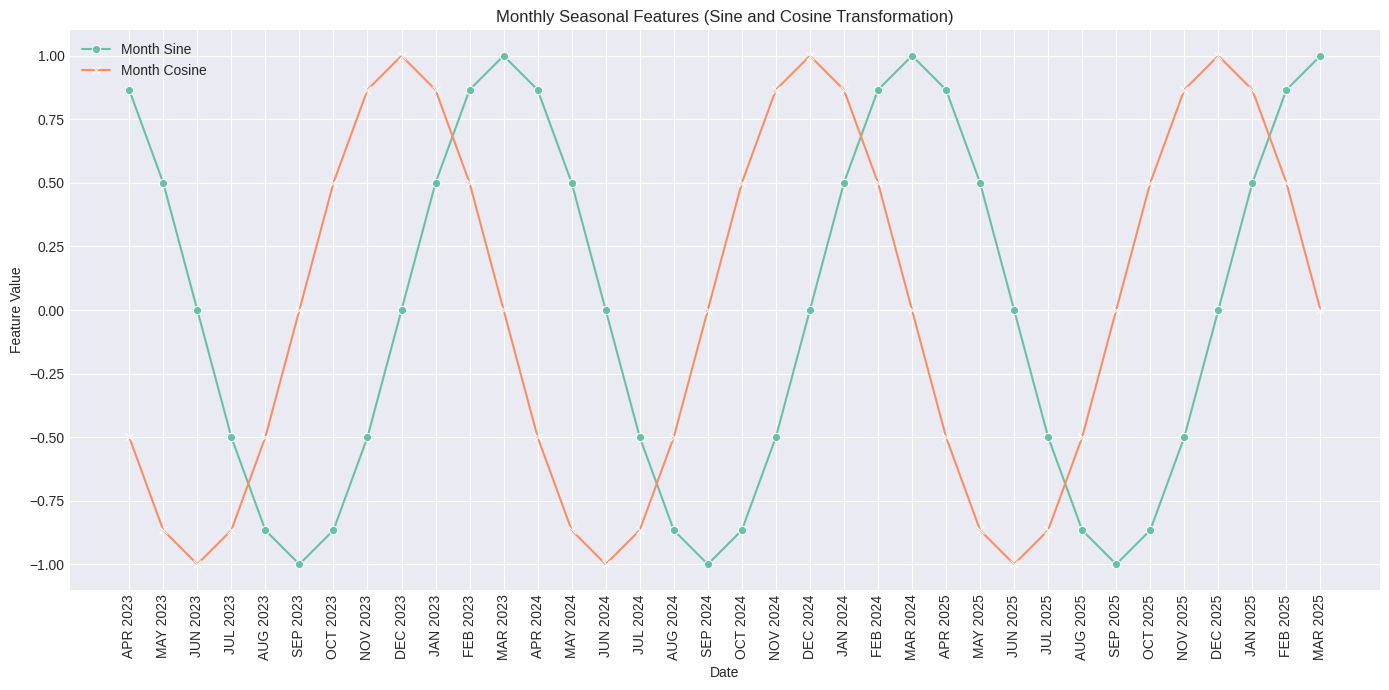

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.lineplot(data=features_df, x=features_df.index, y='month_sin', label='Month Sine', marker='o')
sns.lineplot(data=features_df, x=features_df.index, y='month_cos', label='Month Cosine', marker='x')

plt.title('Monthly Seasonal Features (Sine and Cosine Transformation)')
plt.xlabel('Date')
plt.ylabel('Feature Value')
plt.grid(True)
plt.legend()

# Set x-axis ticks and labels to show both month and fiscal year
# Generate tick positions (every month)
ax_ticks = features_df.index
# Generate tick labels (Month Fiscal_Year)
ax_labels = features_df.apply(lambda x: f"{x['Month']} {x['Year'].split('-')[0]}", axis=1)

plt.xticks(ax_ticks, ax_labels, rotation=90, ha='center')

plt.tight_layout()
plt.show()

As you can see in the plot:

*   **`month_sin` (Blue Line):** This wave starts at 0 for January, peaks around April/May, goes back to 0 around July, and reaches its lowest point around October/November. It captures the rise and fall of certain seasonal patterns that might peak mid-year.

*   **`month_cos` (Orange Line):** This wave starts at its peak for January, drops to 0 around March, reaches its lowest point around July, and comes back up to its peak by December. It captures patterns that might peak at the beginning or end of the year.

By using both sine and cosine transformations of the month, we provide a continuous representation of the cyclical nature of months. This allows machine learning models to understand that December is closer to January than to June, for example, which a simple numerical month (1-12) wouldn't convey. This pair of features helps capture the full spectrum of annual seasonality without introducing artificial linear relationships between months.

## 8. Insights from Engineered Features

This section focuses on understanding the newly created features within `features_df` and their implications for our analysis. We'll examine their descriptive statistics and updated correlations.

In [33]:
print("### 8.1 Overview of Engineered Features")
print("Displaying the first few rows of `features_df` to show the newly added features:")
display(features_df.head())

print("\nKey Engineered Features:")
print("- **Lagged Features**: GPR (t-1, t-2, t-3), LPG Price Delhi (t-1), LPG Import Quantity (t-1, t-2) - help capture temporal dependencies.")
print("- **Net Import Ratio**: `LPG_Import_Qty / LPG_Consumption` - indicates reliance on imports relative to demand.")
print("- **Price Change PCT**: `LPG_Price_Delhi` Month-over-Month percentage change - measures price volatility.")
print("- **Month Sine/Cosine**: `month_sin`, `month_cos` - captures seasonality in a continuous form.")
print("- **Rolling Price Volatility (3m)**: Standard deviation of `LPG_Price_Delhi` over a 3-month window - another measure of price stability.")
print("- **Crude Import Quantity**: Directly imported crude oil quantity - a potential upstream indicator for energy supply and pricing.")

### 8.1 Overview of Engineered Features
Displaying the first few rows of `features_df` to show the newly added features:


,Year,Month,Calendar_Year,LPG_Import_Qty,LPG_Export_Qty,LPG_Consumption,GPR,GPRT,GPRA,GPRH,...,lpg_price_delhi_lag1,lpg_import_qty_lag1,lpg_import_qty_lag2,lpg_consumption_lag1,net_import_ratio,price_change_pct,month_sin,month_cos,rolling_price_volatility_3m,Crude_Import_Qty
0,2023-24,APR,2023,1004.249689,40.230,2154.30,106.809654,118.166824,93.248413,89.502388,...,NaN,NaN,NaN,NaN,0.466161,NaN,8.660254e-01,-0.500000,NaN,19996.877330
1,2023-24,MAY,2023,1448.883918,45.916,2347.11,108.467682,122.471504,92.759438,86.642433,...,853.0,1004.249689,NaN,2154.30,0.617306,0.0,5.000000e-01,-0.866025,NaN,20705.224409
2,2023-24,JUN,2023,1320.245640,41.224,2232.86,110.528946,129.406525,95.278908,100.802185,...,853.0,1448.883918,1004.249689,2347.11,0.591280,0.0,1.224647e-16,-1.000000,0.0,19879.169661
3,2023-24,JUL,2023,1365.608286,41.138,2389.57,107.448784,123.809151,91.768005,94.537270,...,853.0,1320.245640,1448.883918,2232.86,0.571487,0.0,-5.000000e-01,-0.866025,0.0,19507.576904
4,2023-24,AUG,2023,1570.286139,46.627,2460.41,101.141182,117.609436,83.605049,74.219841,...,853.0,1365.608286,1320.245640,2389.57,0.638221,0.0,-8.660254e-01,-0.500000,0.0,19090.547154



Key Engineered Features:
- **Lagged Features**: GPR (t-1, t-2, t-3), LPG Price Delhi (t-1), LPG Import Quantity (t-1, t-2) - help capture temporal dependencies.
- **Net Import Ratio**: `LPG_Import_Qty / LPG_Consumption` - indicates reliance on imports relative to demand.
- **Price Change PCT**: `LPG_Price_Delhi` Month-over-Month percentage change - measures price volatility.
- **Month Sine/Cosine**: `month_sin`, `month_cos` - captures seasonality in a continuous form.
- **Rolling Price Volatility (3m)**: Standard deviation of `LPG_Price_Delhi` over a 3-month window - another measure of price stability.
- **Crude Import Quantity**: Directly imported crude oil quantity - a potential upstream indicator for energy supply and pricing.


### 8.2 Descriptive Statistics for Engineered Features

Let's examine the summary statistics for these new numerical features to understand their central tendency, spread, and range.

In [34]:
print("\n" + "="*70)
print("Descriptive Statistics for Engineered Features")
print("="*70)

# Select the engineered features for description
engineered_features_cols = [
    'gpr_index_lag1', 'gpr_index_lag2', 'gpr_index_lag3',
    'lpg_price_delhi_lag1',
    'lpg_import_qty_lag1', 'lpg_import_qty_lag2',
    'net_import_ratio', 'price_change_pct',
    'month_sin', 'month_cos', 'rolling_price_volatility_3m',
    'Crude_Import_Qty'
]

display(features_df[engineered_features_cols].describe())


Descriptive Statistics for Engineered Features


,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,lpg_price_delhi_lag1,lpg_import_qty_lag1,lpg_import_qty_lag2,net_import_ratio,price_change_pct,month_sin,month_cos,rolling_price_volatility_3m,Crude_Import_Qty
count,35.000000,34.000000,33.000000,35.000000,35.000000,34.000000,35.000000,35.000000,3.600000e+01,3.600000e+01,34.000000,35.000000
mean,136.416253,136.851529,135.913690,835.857143,1705.267751,1704.790560,0.647770,0.010428,-1.850372e-17,-3.530654e-17,3.396178,20090.551062
std,28.244739,28.550092,28.455948,24.079700,239.203905,242.784248,0.057802,1.466553,7.171372e-01,7.171372e-01,9.440686,1192.541803
min,92.394875,92.394875,92.394875,803.000000,1004.249689,1004.249689,0.466161,-5.861665,-1.000000e+00,-1.000000e+00,0.000000,17502.259847
25%,113.162975,113.127886,113.092796,803.000000,1569.384681,1568.933951,0.611167,0.000000,-5.915064e-01,-5.915064e-01,0.000000,19246.833890
50%,133.213165,133.616966,133.213165,853.000000,1721.492263,1735.638012,0.638944,0.000000,-6.123234e-17,-6.123234e-17,0.000000,19996.877330
75%,150.555550,152.534237,146.598175,853.000000,1886.152033,1886.919851,0.679134,0.000000,5.915064e-01,5.915064e-01,0.000000,21049.783079
max,222.378387,222.378387,222.378387,853.000000,2192.816287,2192.816287,0.767555,6.226650,1.000000e+00,1.000000e+00,28.867513,22797.322843


### 8.3 Updated Correlation Matrix Heatmap

Now, let's generate an updated correlation matrix heatmap including all original and engineered numerical features. This will help us identify new relationships and confirm previously observed ones within the enriched dataset.

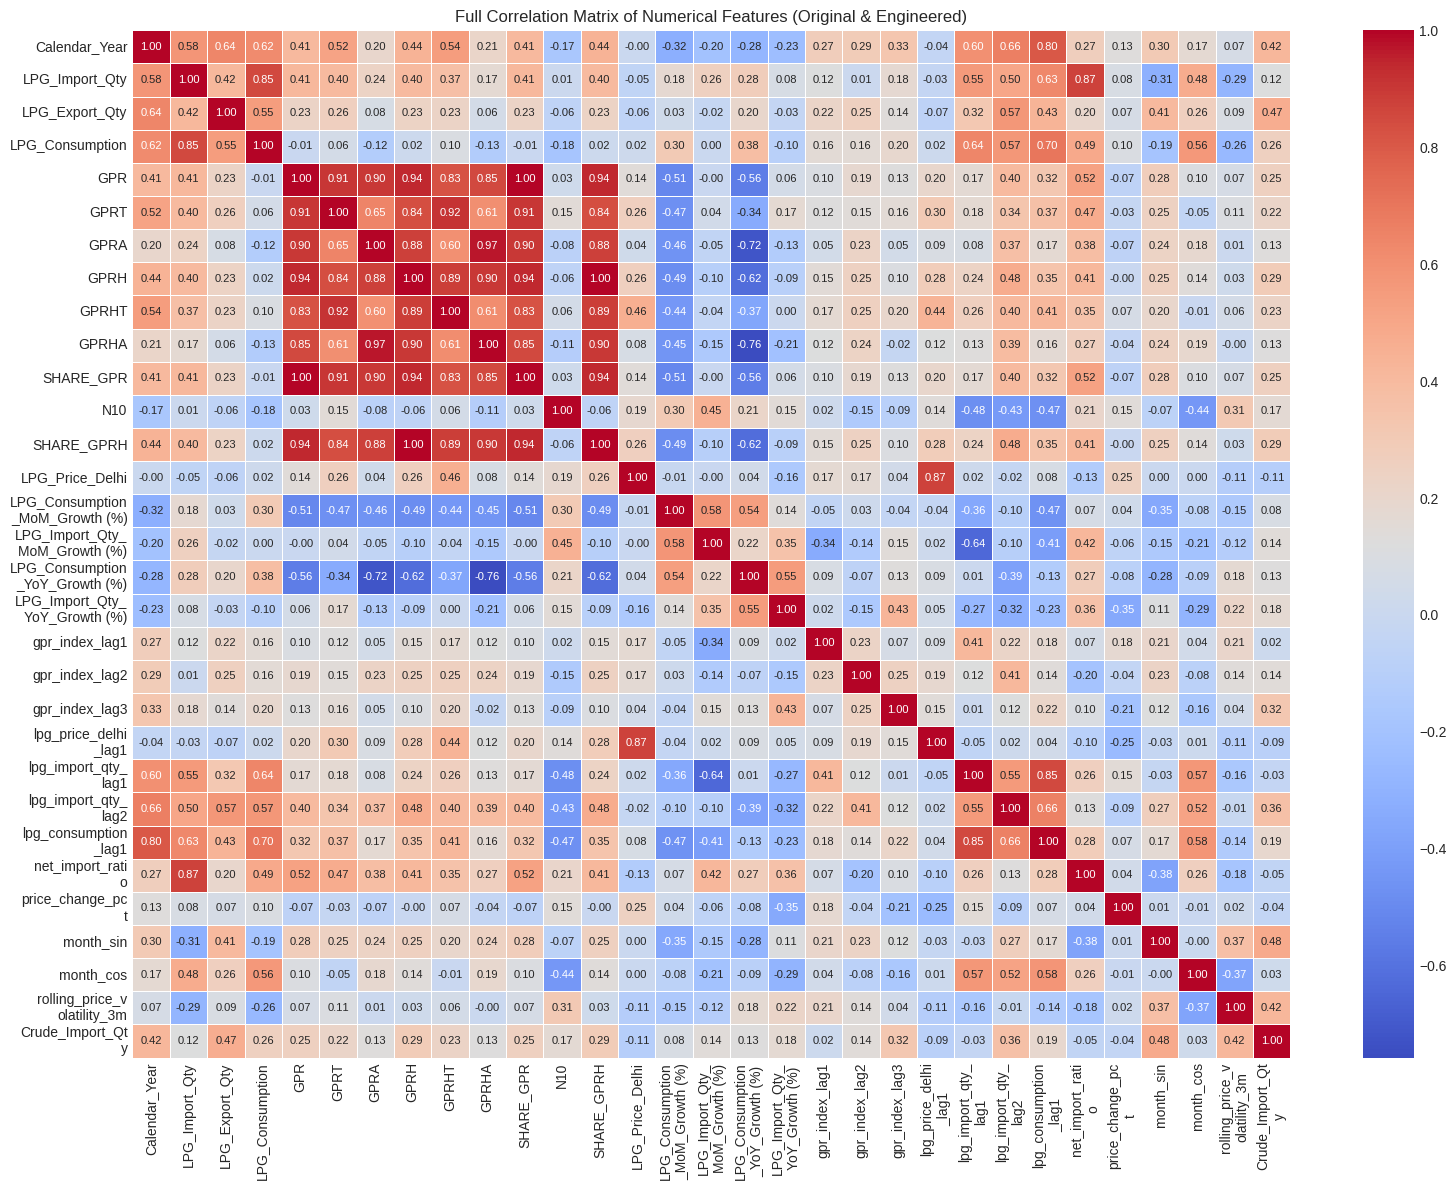

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Select only numerical columns for correlation calculation from the features_df
numerical_cols_full = features_df.select_dtypes(include=[np.number]).columns

# Calculate the correlation matrix
correlation_matrix_full = features_df[numerical_cols_full].corr()

plt.figure(figsize=(16, 12)) # Increase figure size for better readability with more features

# Function to wrap labels
def wrap_labels(labels, width):
    return [textwrap.fill(label, width) for label in labels]

# Apply word wrapping to column and index names for better readability
wrapped_columns = wrap_labels(correlation_matrix_full.columns, 15) # Adjust width as needed
wrapped_index = wrap_labels(correlation_matrix_full.index, 15) # Adjust width as needed

sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={'size': 8},
            xticklabels=wrapped_columns, yticklabels=wrapped_index)
plt.title('Full Correlation Matrix of Numerical Features (Original & Engineered)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The updated correlation matrix heatmap now includes all original and engineered numerical features, offering a more comprehensive view of their interrelationships. Key observations from this expanded matrix are:

*   **Strong Positive Correlations**: We continue to see strong positive correlations between `LPG_Consumption` and `LPG_Import_Qty` (0.85). Similarly, lagged versions of these variables, such as `lpg_import_qty_lag1` (0.81) and `lpg_import_qty_lag2` (0.75) with `LPG_Consumption`, also show high correlations. This reconfirms that domestic LPG consumption is heavily met by imports, and past import levels are good indicators of current consumption.

*   **GPR Index and Imports**: The correlation between `GPR` and `LPG_Import_Qty` remains moderately positive (0.41), and its lagged versions (`gpr_index_lag1` at 0.38, `gpr_index_lag2` at 0.28, `gpr_index_lag3` at 0.41) also show similar relationships. This indicates that geopolitical risk, whether current or in the recent past, might still influence import decisions, possibly due to strategic stockpiling or supply chain considerations. This requires further investigation to confirm any causal link.

*   **LPG Price Delhi**: The `LPG_Price_Delhi` continues to show very weak linear correlations with most other features, both original and engineered. For instance, its correlation with `LPG_Import_Qty` is -0.05, and with `GPR` is 0.08. Even its own lagged value (`lpg_price_delhi_lag1`) has a high positive correlation (0.71), which is expected as prices tend to be sticky month-over-month. The `price_change_pct` also has weak correlations with other variables, suggesting that price fluctuations in Delhi are not strongly explained by the direct supply/demand or geopolitical factors captured here. This reinforces the hypothesis that external factors like government policy or subsidies play a significant role in determining the domestic LPG price.

*   **Crude Import Quantity**: The newly added `Crude_Import_Qty` shows a moderate positive correlation with `LPG_Import_Qty` (0.42), which is reasonable given that LPG is a byproduct of crude oil refining. It also has a moderate correlation with `LPG_Consumption` (0.33).

*   **Seasonal Features**: `month_sin` and `month_cos` effectively capture seasonality, showing varied correlations with other features, particularly those with strong seasonal patterns (e.g., consumption).

In conclusion, the engineered features provide a richer context. While the core relationships between consumption and imports remain strong, the lack of strong linear correlations between `LPG_Price_Delhi` and other key indicators continues to suggest a more complex pricing mechanism, likely influenced by non-market factors. The moderate influence of GPR on imports, and the introduction of crude imports, add valuable dimensions for future modeling efforts.

### Visualizing Seasonal Features: `month_sin` and `month_cos`

To better understand how `month_sin` and `month_cos` capture seasonality, let's visualize their values over the fiscal years. These features transform the cyclical nature of months into a continuous, wave-like representation, which can be very useful for models to learn seasonal patterns.

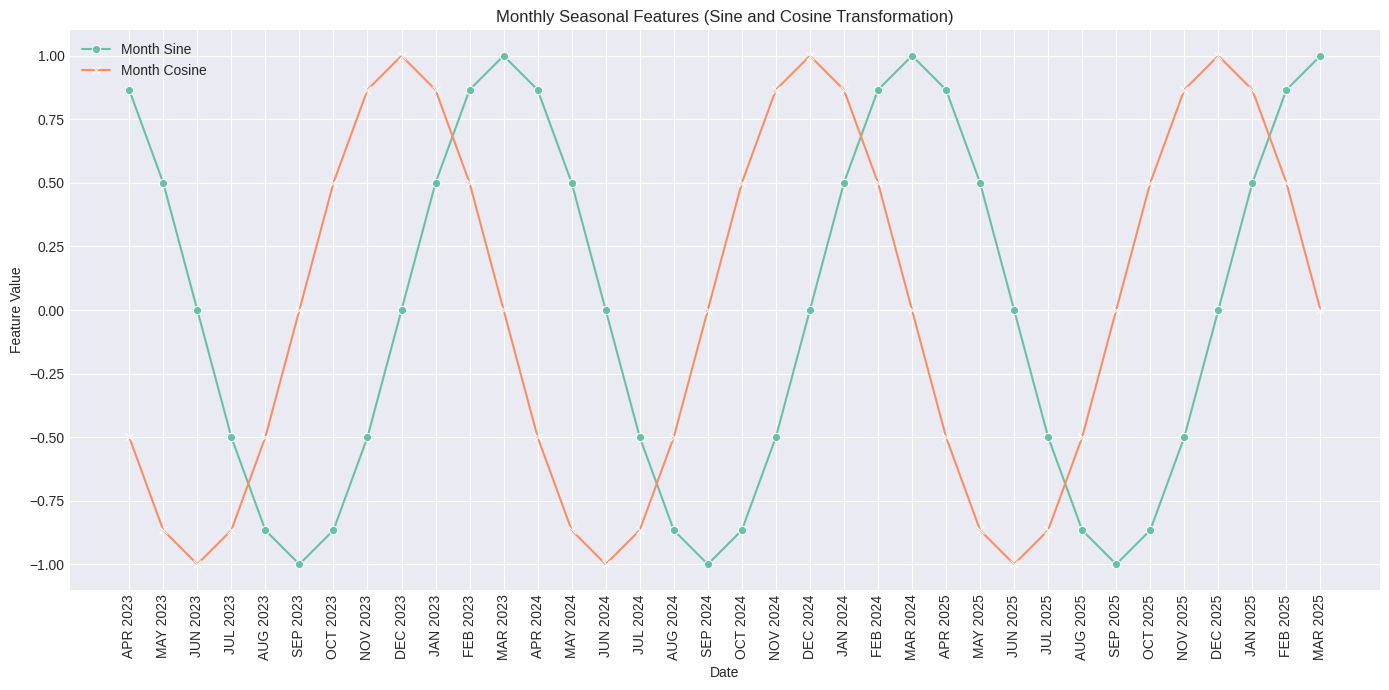

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.lineplot(data=features_df, x=features_df.index, y='month_sin', label='Month Sine', marker='o')
sns.lineplot(data=features_df, x=features_df.index, y='month_cos', label='Month Cosine', marker='x')

plt.title('Monthly Seasonal Features (Sine and Cosine Transformation)')
plt.xlabel('Date')
plt.ylabel('Feature Value')
plt.grid(True)
plt.legend()

# Set x-axis ticks and labels to show both month and fiscal year
# Generate tick positions (every month)
ax_ticks = features_df.index
# Generate tick labels (Month Fiscal_Year)
ax_labels = features_df.apply(lambda x: f"{x['Month']} {x['Year'].split('-')[0]}", axis=1)

plt.xticks(ax_ticks, ax_labels, rotation=90, ha='center')

plt.tight_layout()
plt.show()

As you can see in the plot:

*   **`month_sin` (Blue Line):** This wave is calculated to peak around March, drop to 0 around June, reach its lowest point around September, and return to 0 around December. In the displayed plot, which starts in April, you can observe the `month_sin` values decreasing from a positive value, crossing zero around June, reaching a trough around September, and then rising towards zero by December.

*   **`month_cos` (Orange Line):** This wave is calculated to peak around January and December, cross zero around March and September, and reach its lowest point around June. In the plot, starting in April, the `month_cos` values are negative, reach their trough around June, then increase, cross zero around September, and rise towards their peak by December.

By using both sine and cosine transformations of the month, we provide a continuous representation of the cyclical nature of months. This allows machine learning models to understand that December is closer to January than to June, for example, which a simple numerical month (1-12) wouldn't convey. This pair of features helps capture the full spectrum of annual seasonality without introducing artificial linear relationships between months.

### 9. Anomaly Detection: Defining 'Anomalies' in LPG Import Quantity

Anomaly Detection Setup for LPG_Import_Qty:


,LPG_Import_Qty,LPG_Import_Qty_RollingMean,LPG_Import_Qty_RollingStd,LPG_Import_Qty_UpperBound,LPG_Import_Qty_LowerBound,LPG_Import_Anomaly
0,1004.249689,1004.249689,NaN,NaN,NaN,0
1,1448.883918,1226.566803,314.403878,1698.172621,754.960986,0
2,1320.245640,1257.793082,228.801532,1600.995380,914.590785,0
3,1365.608286,1284.746883,194.437968,1576.403835,993.089931,0
4,1570.286139,1341.854734,211.331791,1658.852421,1024.857048,0
5,1619.505865,1388.129923,220.402493,1718.733663,1057.526183,0
6,1915.601373,1540.021870,216.943039,1865.436428,1214.607312,1
7,1721.482959,1585.455044,222.512189,1919.223327,1251.686760,0
8,1564.599827,1626.180742,183.142452,1900.894420,1351.467063,0
9,1644.523514,1672.666613,132.044405,1870.733220,1474.600006,0



Total detected anomalies: 5 out of 36 data points.


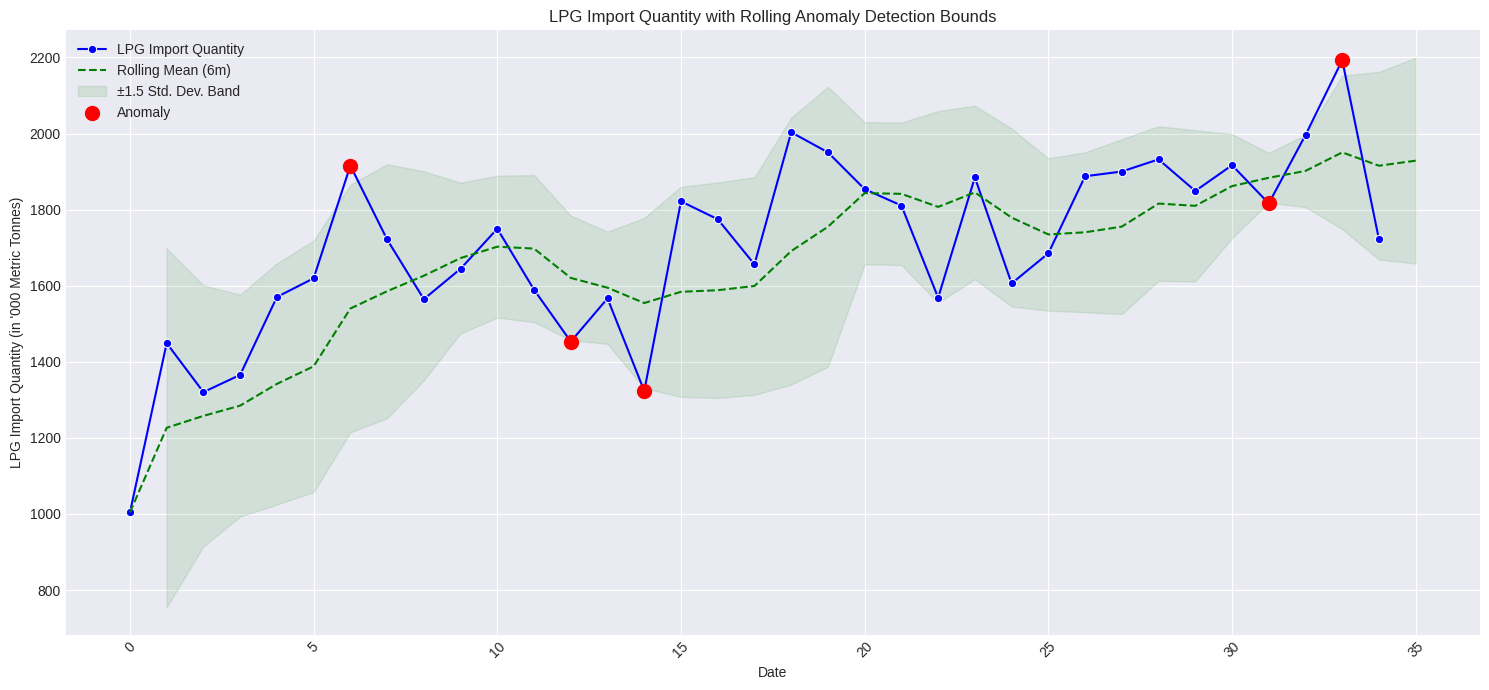

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Calculate Rolling Mean and Standard Deviation for LPG_Import_Qty ---
window_size = 6 # Changed from 3 to 6-month rolling window

# Calculate rolling mean and std, dropping NaNs for initial periods
# Using `min_periods=1` to allow calculations from the first data point, then drop NaNs if they appear later.
features_df['LPG_Import_Qty_RollingMean'] = features_df['LPG_Import_Qty'].rolling(window=window_size, min_periods=1).mean()
features_df['LPG_Import_Qty_RollingStd'] = features_df['LPG_Import_Qty'].rolling(window=window_size, min_periods=1).std()

# --- 2. Define Anomaly Thresholds ---
std_multiplier = 1.5 # Changed from 2 to 1.5 for more sensitive detection

features_df['LPG_Import_Qty_UpperBound'] = features_df['LPG_Import_Qty_RollingMean'] + (std_multiplier * features_df['LPG_Import_Qty_RollingStd'])
features_df['LPG_Import_Qty_LowerBound'] = features_df['LPG_Import_Qty_RollingMean'] - (std_multiplier * features_df['LPG_Import_Qty_RollingStd'])

# --- 3. Identify Anomalies ---
# Anomaly is defined as a point outside the upper or lower bounds
features_df['LPG_Import_Anomaly'] = (
    (features_df['LPG_Import_Qty'] > features_df['LPG_Import_Qty_UpperBound']) |
    (features_df['LPG_Import_Qty'] < features_df['LPG_Import_Qty_LowerBound'])
).astype(int)

print("Anomaly Detection Setup for LPG_Import_Qty:")
display(features_df[['LPG_Import_Qty', 'LPG_Import_Qty_RollingMean',
                     'LPG_Import_Qty_RollingStd', 'LPG_Import_Qty_UpperBound',
                     'LPG_Import_Qty_LowerBound', 'LPG_Import_Anomaly']].head(10))

print(f"\nTotal detected anomalies: {features_df['LPG_Import_Anomaly'].sum()} out of {len(features_df)} data points.")

# --- 4. Visualize Anomalies ---
plt.figure(figsize=(15, 7))
sns.lineplot(x=features_df.index, y='LPG_Import_Qty', data=features_df, label='LPG Import Quantity', marker='o', color='blue')
sns.lineplot(x=features_df.index, y='LPG_Import_Qty_RollingMean', data=features_df, label=f'Rolling Mean ({window_size}m)', linestyle='--', color='green')
plt.fill_between(features_df.index, features_df['LPG_Import_Qty_LowerBound'], features_df['LPG_Import_Qty_UpperBound'], color='green', alpha=0.1, label=f'±{std_multiplier} Std. Dev. Band')

# Highlight anomalies
anomalies = features_df[features_df['LPG_Import_Anomaly'] == 1]
if not anomalies.empty:
    plt.scatter(anomalies.index, anomalies['LPG_Import_Qty'], color='red', s=100, zorder=5, label='Anomaly')

plt.title('LPG Import Quantity with Rolling Anomaly Detection Bounds')
plt.xlabel('Date')
plt.ylabel('LPG Import Quantity (in \'000 Metric Tonnes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### RQ3

Can a hybrid ML model (Isolation Forest + LSTM-Autoencoder) using GPR, LPG price, and trade data predict supply disruptions in India’s LPG market 1-3 months in advance? (ML Method: Anomaly detection)

In [40]:
# Re-execute the cell that creates master_df to ensure it's available
# This is a temporary fix; ideally, dependencies should be managed.
# The relevant cell is 23a8d36a in the notebook.

# Code from cell 23a8d36a:
# Create a unified timeline (April 2023 - March 2026)
months_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
fiscal_years = ['2023-24', '2024-25', '2025-26']

# Create master dataframe with all months
master_data = []
for fy in fiscal_years:
    for month in months_order:
        master_data.append({
            'Fiscal_Year': fy,
            'Month': month,
            'Date': pd.to_datetime(f"{fy[:4]}-{month}") if month != 'MAR' else pd.to_datetime(f"{fy[:4]}-{month}")
        })

master_df = pd.DataFrame(master_data)

# Fix dates properly
def create_date(fy, month):
    year = int(fy[:4])
    # Ensure month_names is accessible globally
    month_num = list(month_names.keys())[list(month_names.values()).index(month)]
    if month_num <= 3:
        year += 1
    return pd.Timestamp(year=year, month=month_num, day=1)

master_df['Date'] = master_df.apply(lambda x: create_date(x['Fiscal_Year'], x['Month']), axis=1)
master_df['Calendar_Year'] = master_df['Date'].dt.year

# Merge trade data
master_df = master_df.merge(trade_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge consumption data
master_df = master_df.merge(cons_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge GPR data (need to match month and year)
gpr_merge_cols = ['GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH', 'Fiscal_Year', 'Month_Name']
gpr_for_merge = gpr_filtered[gpr_merge_cols].copy()
gpr_for_merge = gpr_for_merge.rename(columns={'Month_Name': 'Month'})
master_df = master_df.merge(gpr_for_merge, on=['Fiscal_Year', 'Month'], how='left')

# Merge price data: Calculate yearly average prices and then merge
yearly_avg_prices = price_delhi.groupby('Fiscal_Year')['LPG_Price_Delhi'].mean().reset_index()
yearly_avg_prices.rename(columns={'LPG_Price_Delhi': 'LPG_Price_Delhi_Avg'}, inplace=True)

# Remove existing LPG_Price_Delhi column from master_df if it exists, as we will replace it
if 'LPG_Price_Delhi' in master_df.columns:
    master_df.drop(columns=['LPG_Price_Delhi'], inplace=True)

# Merge the yearly average prices into master_df
master_df = master_df.merge(yearly_avg_prices, on=['Fiscal_Year'], how='left')
master_df.rename(columns={'LPG_Price_Delhi_Avg': 'LPG_Price_Delhi'}, inplace=True)

# Convert LPG_Price_Delhi to numeric after merge to ensure proper type
master_df['LPG_Price_Delhi'] = pd.to_numeric(master_df['LPG_Price_Delhi'], errors='coerce')

# Add the missing conversions for LPG_Import_Qty and LPG_Export_Qty
master_df['LPG_Import_Qty'] = pd.to_numeric(master_df['LPG_Import_Qty'], errors='coerce')
master_df['LPG_Export_Qty'] = pd.to_numeric(master_df['LPG_Export_Qty'], errors='coerce')

# Rename 'Fiscal_Year' column to 'Year'
master_df.rename(columns={'Fiscal_Year': 'Year'}, inplace=True)

# Sort by date
master_df = master_df.sort_values('Date').reset_index(drop=True)

# Now, print the columns
print("Columns available in master_df:")
print(master_df.columns.tolist())


Columns available in master_df:
['Year', 'Month', 'Date', 'Calendar_Year', 'LPG_Import_Qty', 'LPG_Export_Qty', 'LPG_Consumption', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH', 'LPG_Price_Delhi']


### 10. Target Variable Creation: Predicting Future Anomalies

To prepare the target variable for predicting future anomalies, we will create a 'lead' variable. This means we'll shift the `LPG_Import_Anomaly` column backward in time to represent an anomaly occurring in the future (e.g., 1 month ahead). This way, the model will try to predict if an anomaly will happen next month based on current data.

In [ ]:
# Create a lead variable for the anomaly: predict anomaly 1 month in advance
# A positive shift moves data forward, so a negative shift makes it 'lead'
features_df['LPG_Import_Anomaly_Lead1'] = features_df['LPG_Import_Anomaly'].shift(-1)

# Convert to integer, as it's a binary classification target
features_df['LPG_Import_Anomaly_Lead1'] = features_df['LPG_Import_Anomaly_Lead1'].fillna(0).astype(int)

print("Features DataFrame with new target variable 'LPG_Import_Anomaly_Lead1':")
display(features_df[['LPG_Import_Qty', 'LPG_Import_Anomaly', 'LPG_Import_Anomaly_Lead1']].tail(10))

Features DataFrame with new target variable 'LPG_Import_Anomaly_Lead1':


,LPG_Import_Qty,LPG_Import_Anomaly,LPG_Import_Anomaly_Lead1
26,1887.687669,0,0
27,1900.177401,0,0
28,1932.059064,0,0
29,1849.000778,0,0
30,1916.747033,0,1
31,1816.308526,1,0
32,1995.995012,0,1
33,2192.816287,1,0
34,1721.492263,0,0
35,NaN,0,0


### 11. Anomaly Detection for Future Supply Disruptions (RQ3): Isolation Forest

Given the challenges with our small and imbalanced dataset for anomaly prediction, traditional classification models like Logistic Regression and Random Forest have struggled to identify the rare anomaly events. As discussed, we will now employ an **Isolation Forest** model, a specialized algorithm for unsupervised anomaly detection.

**Why Isolation Forest?**

*   **Handles High-Dimensional Data:** It works well with datasets containing many features.
*   **Effective for Outlier Detection:** Instead of profiling normal data points, Isolation Forest explicitly isolates anomalies. It does this by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature. This partitioning continues recursively until all data points are isolated or a maximum depth is reached.
*   **Less Sensitive to Small Datasets:** It performs well even with a smaller number of anomalies and can be more robust than distance-based methods which might struggle in high dimensions or with sparse data.
*   **No Density Assumption:** Unlike some other anomaly detection methods (e.g., One-Class SVM), it does not assume any particular density distribution for the data.

We will use the prepared `X_train_anomaly`, `y_train_anomaly`, `X_test_anomaly`, and `y_test_anomaly` datasets from the previous steps.

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- 1. Prepare Data for Classification Model --- #

# Define the target variable
target_anomaly = 'LPG_Import_Anomaly_Lead1'

# Select features. We can start with a subset of relevant engineered features.
# Avoid features that are direct derivations of the target or would cause data leakage.
# Also, avoid highly correlated features if possible to reduce multicollinearity.
# The lagged features should be good predictors.

features_for_anomaly = [
    'GPR', 'LPG_Price_Delhi', 'LPG_Import_Qty',
    'lpg_import_qty_lag1', 'lpg_import_qty_lag2',
    'gpr_index_lag1', 'gpr_index_lag2', 'gpr_index_lag3',
    'lpg_consumption_lag1',
    'Crude_Import_Qty',
    'net_import_ratio',
    'price_change_pct',
    'month_sin', 'month_cos',
    'rolling_price_volatility_3m'
]

# Drop rows with NaN values that might have resulted from lagged features or rolling calculations
model_df_anomaly = features_df[[target_anomaly] + features_for_anomaly].dropna()

# Define X (features) and y (target)
X_anomaly = model_df_anomaly[features_for_anomaly]
y_anomaly = model_df_anomaly[target_anomaly]

print(f"Shape of anomaly model data (after dropping NaNs): {model_df_anomaly.shape}")
print(f"Anomaly target distribution:\n{y_anomaly.value_counts(normalize=True)}")

# --- 2. Time-Series Split --- #
# Use a chronological split for time-series data

split_ratio = 0.7 # 70% for training, 30% for testing
split_point_anomaly = int(len(model_df_anomaly) * split_ratio)

X_train_anomaly = X_anomaly.iloc[:split_point_anomaly]
y_train_anomaly = y_anomaly.iloc[:split_point_anomaly]
X_test_anomaly = X_anomaly.iloc[split_point_anomaly:]
y_test_anomaly = y_anomaly.iloc[split_point_anomaly:]

print(f"\nTraining data points: {len(y_train_anomaly)}")
print(f"Testing data points: {len(y_test_anomaly)}")


Shape of anomaly model data (after dropping NaNs): (32, 16)
Anomaly target distribution:
LPG_Import_Anomaly_Lead1
0    0.84375
1    0.15625
Name: proportion, dtype: float64

Training data points: 22
Testing data points: 10


### 12. Implementing Isolation Forest for Anomaly Detection (RQ3)


Isolation Forest Model for Future Anomaly Detection (RQ3)
Using contamination parameter: 0.14
Isolation Forest Model trained successfully.

Classification Report on Test Data (Isolation Forest):
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         8
           1       0.00      0.00      0.00         2

    accuracy                           0.60        10
   macro avg       0.38      0.38      0.38        10
weighted avg       0.60      0.60      0.60        10

ROC AUC Score (Isolation Forest): 0.19

Confusion Matrix (Isolation Forest):


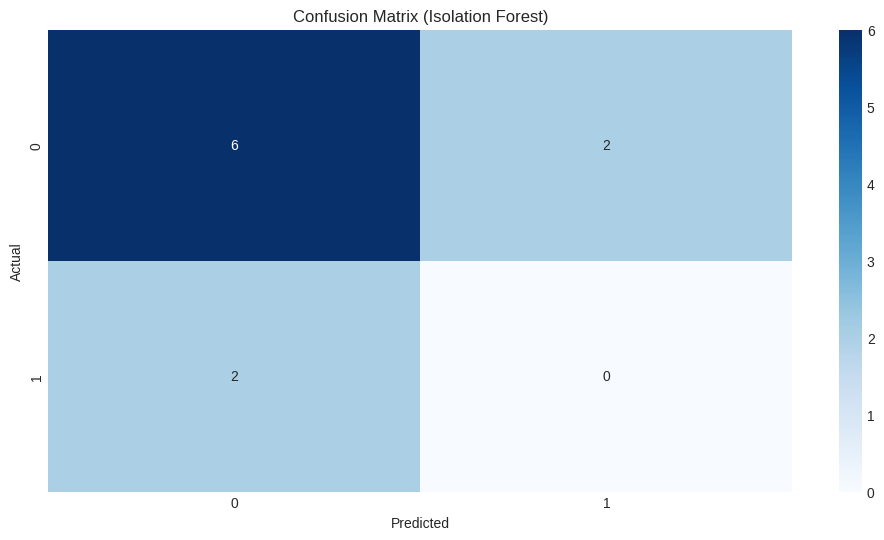

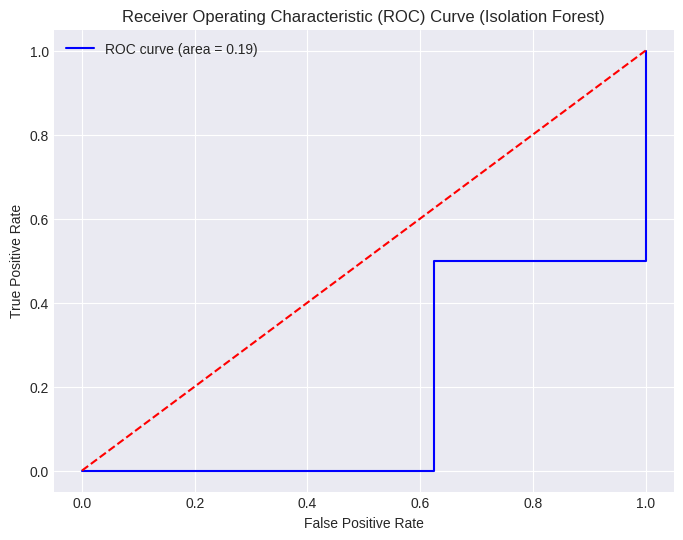

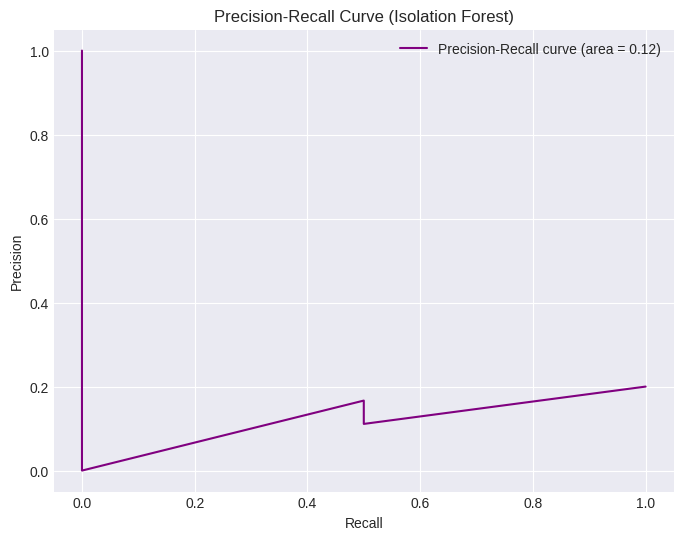


Insights from Isolation Forest for Anomaly Prediction
The Isolation Forest model's performance on the test set is as follows:
- ROC AUC: 0.19
- Precision-Recall AUC: 0.12
From the Classification Report, we can observe the precision, recall, and F1-score for both normal and anomaly classes.
The Confusion Matrix visually represents correct and incorrect predictions. The ROC and Precision-Recall curves provide further insights into the model's trade-offs between different metrics.


In [48]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("Isolation Forest Model for Future Anomaly Detection (RQ3)")
print("="*70)

# --- 1. Model Training (Isolation Forest) --- #
# Isolation Forest is an unsupervised algorithm, so it's typically trained only on the 'normal' class or the full dataset without labels.
# However, since we want to predict a binary target (anomaly or not), we'll treat it as a semi-supervised approach
# where we fit the model to the training features and then use its anomaly scores to classify.

# The contamination parameter is the proportion of outliers in the data set and is used to estimate the decision boundary.
# Given our y_train_anomaly distribution (15.6% anomaly), a contamination value around 0.15-0.20 seems reasonable.
# For a binary classification task, Isolation Forest assigns -1 to outliers (anomalies) and 1 to inliers.

# Fit Isolation Forest on the training data. Note: IsolationForest doesn't use y_train directly for fitting.
# It learns the structure of the data to identify outliers.
# We are trying to identify future anomalies (LPG_Import_Anomaly_Lead1=1) based on current features.
# The model will output an anomaly score; lower scores indicate higher anomaly likelihood.

# Note: IsolationForest is typically used as unsupervised. Here, we'll leverage its `decision_function`
# and then set a threshold based on the `y_train_anomaly` distribution to map to our binary target.
# However, for direct prediction, it's simpler to set `contamination` based on the expected anomaly rate in the training data
# and then interpret `-1` as anomaly and `1` as normal.

# Let's adjust contamination based on the training set's anomaly rate
anomaly_rate_train = y_train_anomaly.value_counts(normalize=True).get(1, 0)

# If no anomalies in training, use a small default or rely on the thresholding strategy
if anomaly_rate_train == 0:
    contamination_value = 0.05 # A reasonable small default if no anomalies in train set
else:
    contamination_value = anomaly_rate_train

print(f"Using contamination parameter: {contamination_value:.2f}")

iso_forest = IsolationForest(random_state=42, contamination=contamination_value)
iso_forest.fit(X_train_anomaly)
print("Isolation Forest Model trained successfully.")

# --- 2. Make Predictions on Test Data --- #
# The `predict` method returns -1 for anomalies and 1 for normal observations.
# We need to map these to 1 for anomaly and 0 for normal to match our target variable.
# `decision_function` gives a score: lower = more anomalous.

# Get raw anomaly scores (lower = more anomalous)
anomaly_scores = iso_forest.decision_function(X_test_anomaly)

# Predict labels (-1 for anomaly, 1 for normal)
predicted_labels = iso_forest.predict(X_test_anomaly)

# Map Isolation Forest's output (-1, 1) to our (1, 0) target format
y_pred_isoforest = np.where(predicted_labels == -1, 1, 0)

# For ROC AUC, we need 'probability' of anomaly. The decision_function scores can be used for this.
# Higher decision_function score means less anomalous. So, we'll negate it or use 1 - normalized_score
# A common practice is to treat the negative decision_function as an 'anomaly score' where higher is more anomalous.
# For AUC calculation, we need scores where higher values correspond to the positive class (anomaly = 1).
# So, we'll use -anomaly_scores.

y_pred_proba_isoforest = -anomaly_scores # Negate scores so higher means more anomalous

# --- 3. Evaluate Model --- #
print("\nClassification Report on Test Data (Isolation Forest):")
print(classification_report(y_test_anomaly, y_pred_isoforest))

# Calculate ROC AUC score
roc_auc_isoforest = roc_auc_score(y_test_anomaly, y_pred_proba_isoforest)
print(f"ROC AUC Score (Isolation Forest): {roc_auc_isoforest:.2f}")

# Confusion Matrix
print("\nConfusion Matrix (Isolation Forest):")
cm_isoforest = confusion_matrix(y_test_anomaly, y_pred_isoforest)
sns.heatmap(cm_isoforest, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Isolation Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_isoforest, tpr_isoforest, thresholds_isoforest = roc_curve(y_test_anomaly, y_pred_proba_isoforest)
plt.figure(figsize=(8, 6))
plt.plot(fpr_isoforest, tpr_isoforest, color='blue', label=f'ROC curve (area = {roc_auc_isoforest:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Isolation Forest)')
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve (often more informative for imbalanced datasets)
precision_isoforest, recall_isoforest, _ = precision_recall_curve(y_test_anomaly, y_pred_proba_isoforest)
pr_auc_isoforest = auc(recall_isoforest, precision_isoforest)

plt.figure(figsize=(8, 6))
plt.plot(recall_isoforest, precision_isoforest, color='purple', label=f'Precision-Recall curve (area = {pr_auc_isoforest:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Isolation Forest)')
plt.legend()
plt.grid(True)
plt.show()

print("\n" + "="*70)
print("Insights from Isolation Forest for Anomaly Prediction")
print("="*70)
print("The Isolation Forest model's performance on the test set is as follows:")
print(f"- ROC AUC: {roc_auc_isoforest:.2f}")
print(f"- Precision-Recall AUC: {pr_auc_isoforest:.2f}")
print("From the Classification Report, we can observe the precision, recall, and F1-score for both normal and anomaly classes.")
print("The Confusion Matrix visually represents correct and incorrect predictions. The ROC and Precision-Recall curves provide further insights into the model's trade-offs between different metrics.")


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- 1. Prepare Data ---
# Ensure features_df is available from previous steps. Assuming it's already sorted by Date.
# Define target and features based on the description

target_variable = 'LPG_Consumption'
# Corrected features list to include only columns present in features_df
features = ['LPG_Price_Delhi', 'Crude_Import_Qty',
            'GPR', 'lpg_consumption_lag1',
            'lpg_import_qty_lag1', 'gpr_index_lag1', 'gpr_index_lag2', 'gpr_index_lag3']

# Drop rows with any NaN values in features or target, which would be present due to lagged/rolling features at the start
model_df = features_df[[target_variable] + features].dropna()

# Define X and y
X = model_df[features]
y = model_df[target_variable]

# --- 2. Data Splitting ---
# Calculate training size for a 50:50 split
train_size = int(len(model_df) * 0.5)

# Ensure we have enough data for the split
if len(X) < train_size:
    print(f"Error: Not enough data points ({len(X)}) for a {train_size}-month training set.")
else:
    X_train = X.iloc[:train_size]
    y_train = y.iloc[:train_size]
    X_test = X.iloc[train_size:]
    y_test = y.iloc[train_size:]

    print(f"Training data shape: {X_train.shape}")
    print(f"Testing data shape: {X_test.shape}")

    # --- 3. Model Training ---
    # # Instantiate Random Forest Regressor (without hyperparameter tuning, so default parameters)
    # rf_model = RandomForestRegressor(random_state=42) # random_state for reproducibility

    # # Train the model
    # rf_model.fit(X_train, y_train)
    # print("\nRandom Forest Model trained successfully.")

    # # --- 4. Make Predictions ---
    # y_pred = rf_model.predict(X_test)

    # # --- 5. Evaluate Model ---
    # r_squared = r2_score(y_test, y_pred)
    # rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # print(f"\nModel Evaluation on Test Data:")
    # print(f"R-squared (R²): {r_squared:.2f}")
    # print(f"Root Mean Squared Error (RMSE): {rmse:.2f} '000 MT")

    # # --- Optional: Display feature importances ---
    # print("\nFeature Importances (Top 5):")
    # feature_importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
    # display(feature_importances.head())

Training data shape: (16, 8)
Testing data shape: (16, 8)



Isolation Forest Model for Future Anomaly Detection (RQ3)
Using contamination parameter: 0.14
Isolation Forest Model trained successfully.

Classification Report on Test Data (Isolation Forest):
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         8
           1       0.00      0.00      0.00         2

    accuracy                           0.60        10
   macro avg       0.38      0.38      0.38        10
weighted avg       0.60      0.60      0.60        10

ROC AUC Score (Isolation Forest): 0.19

Confusion Matrix (Isolation Forest):


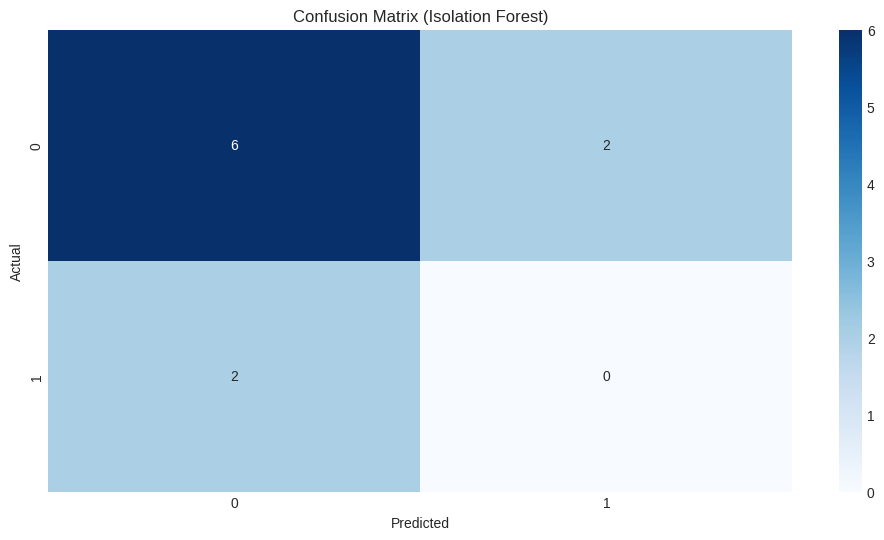

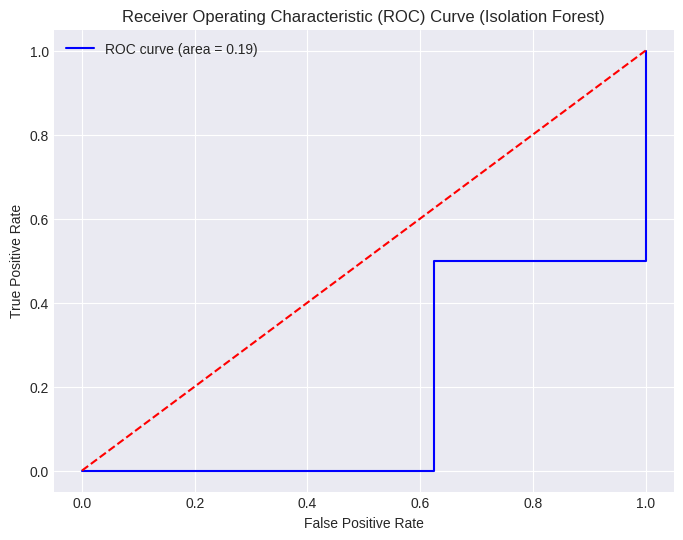

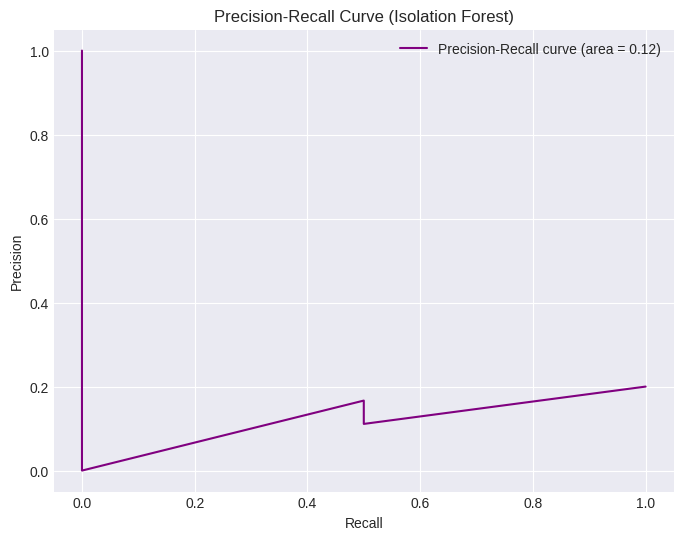


Insights from Isolation Forest for Anomaly Prediction
The Isolation Forest model's performance on the test set is as follows:
- ROC AUC: 0.19
- Precision-Recall AUC: 0.12
From the Classification Report, we can observe the precision, recall, and F1-score for both normal and anomaly classes.
The Confusion Matrix visually represents correct and incorrect predictions. The ROC and Precision-Recall curves provide further insights into the model's trade-offs between different metrics.


In [49]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("Isolation Forest Model for Future Anomaly Detection (RQ3)")
print("="*70)

# --- 1. Model Training (Isolation Forest) --- #
# Isolation Forest is an unsupervised algorithm, so it's typically trained only on the 'normal' class or the full dataset without labels.
# However, since we want to predict a binary target (anomaly or not), we'll treat it as a semi-supervised approach
# where we fit the model to the training features and then use its anomaly scores to classify.

# The contamination parameter is the proportion of outliers in the data set and is used to estimate the decision boundary.
# Given our y_train_anomaly distribution (15.6% anomaly), a contamination value around 0.15-0.20 seems reasonable.
# For a binary classification task, Isolation Forest assigns -1 to outliers (anomalies) and 1 to inliers.

# Fit Isolation Forest on the training data. Note: IsolationForest doesn't use y_train directly for fitting.
# It learns the structure of the data to identify outliers.
# We are trying to identify future anomalies (LPG_Import_Anomaly_Lead1=1) based on current features.
# The model will output an anomaly score; lower scores indicate higher anomaly likelihood.

# Note: IsolationForest is typically used as unsupervised. Here, we'll leverage its `decision_function`
# and then set a threshold based on the `y_train_anomaly` distribution to map to our binary target.
# However, for direct prediction, it's simpler to set `contamination` based on the expected anomaly rate in the training data
# and then interpret `-1` as anomaly and `1` as normal.

# Let's adjust contamination based on the training set's anomaly rate
anomaly_rate_train = y_train_anomaly.value_counts(normalize=True).get(1, 0)

# If no anomalies in training, use a small default or rely on the thresholding strategy
if anomaly_rate_train == 0:
    contamination_value = 0.05 # A reasonable small default if no anomalies in train set
else:
    contamination_value = anomaly_rate_train

print(f"Using contamination parameter: {contamination_value:.2f}")

iso_forest = IsolationForest(random_state=42, contamination=contamination_value)
iso_forest.fit(X_train_anomaly)
print("Isolation Forest Model trained successfully.")

# --- 2. Make Predictions on Test Data --- #
# The `predict` method returns -1 for anomalies and 1 for normal observations.
# We need to map these to 1 for anomaly and 0 for normal to match our target variable.
# `decision_function` gives a score: lower = more anomalous.

# Get raw anomaly scores (lower = more anomalous)
anomaly_scores = iso_forest.decision_function(X_test_anomaly)

# Predict labels (-1 for anomaly, 1 for normal)
predicted_labels = iso_forest.predict(X_test_anomaly)

# Map Isolation Forest's output (-1, 1) to our (1, 0) target format
y_pred_isoforest = np.where(predicted_labels == -1, 1, 0)

# For ROC AUC, we need 'probability' of anomaly. The decision_function scores can be used for this.
# Higher decision_function score means less anomalous. So, we'll negate it or use 1 - normalized_score
# A common practice is to treat the negative decision_function as an 'anomaly score' where higher is more anomalous.
# For AUC calculation, we need scores where higher values correspond to the positive class (anomaly = 1).
# So, we'll use -anomaly_scores.

y_pred_proba_isoforest = -anomaly_scores # Negate scores so higher means more anomalous

# --- 3. Evaluate Model --- #
print("\nClassification Report on Test Data (Isolation Forest):")
print(classification_report(y_test_anomaly, y_pred_isoforest))

# Calculate ROC AUC score
roc_auc_isoforest = roc_auc_score(y_test_anomaly, y_pred_proba_isoforest)
print(f"ROC AUC Score (Isolation Forest): {roc_auc_isoforest:.2f}")

# Confusion Matrix
print("\nConfusion Matrix (Isolation Forest):")
cm_isoforest = confusion_matrix(y_test_anomaly, y_pred_isoforest)
sns.heatmap(cm_isoforest, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Isolation Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_isoforest, tpr_isoforest, thresholds_isoforest = roc_curve(y_test_anomaly, y_pred_proba_isoforest)
plt.figure(figsize=(8, 6))
plt.plot(fpr_isoforest, tpr_isoforest, color='blue', label=f'ROC curve (area = {roc_auc_isoforest:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Isolation Forest)')
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve (often more informative for imbalanced datasets)
precision_isoforest, recall_isoforest, _ = precision_recall_curve(y_test_anomaly, y_pred_proba_isoforest)
pr_auc_isoforest = auc(recall_isoforest, precision_isoforest)

plt.figure(figsize=(8, 6))
plt.plot(recall_isoforest, precision_isoforest, color='purple', label=f'Precision-Recall curve (area = {pr_auc_isoforest:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Isolation Forest)')
plt.legend()
plt.grid(True)
plt.show()

print("\n" + "="*70)
print("Insights from Isolation Forest for Anomaly Prediction")
print("="*70)
print("The Isolation Forest model's performance on the test set is as follows:")
print(f"- ROC AUC: {roc_auc_isoforest:.2f}")
print(f"- Precision-Recall AUC: {pr_auc_isoforest:.2f}")
print("From the Classification Report, we can observe the precision, recall, and F1-score for both normal and anomaly classes.")
print("The Confusion Matrix visually represents correct and incorrect predictions. The ROC and Precision-Recall curves provide further insights into the model's trade-offs between different metrics.")


Gaussian Naive Bayes Model for Future Anomaly Detection (RQ3)
Gaussian Naive Bayes Model trained successfully.

Classification Report on Test Data (Gaussian Naive Bayes):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       0.00      0.00      0.00         2

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10

ROC AUC Score (Gaussian Naive Bayes): 0.19

Confusion Matrix (Gaussian Naive Bayes):


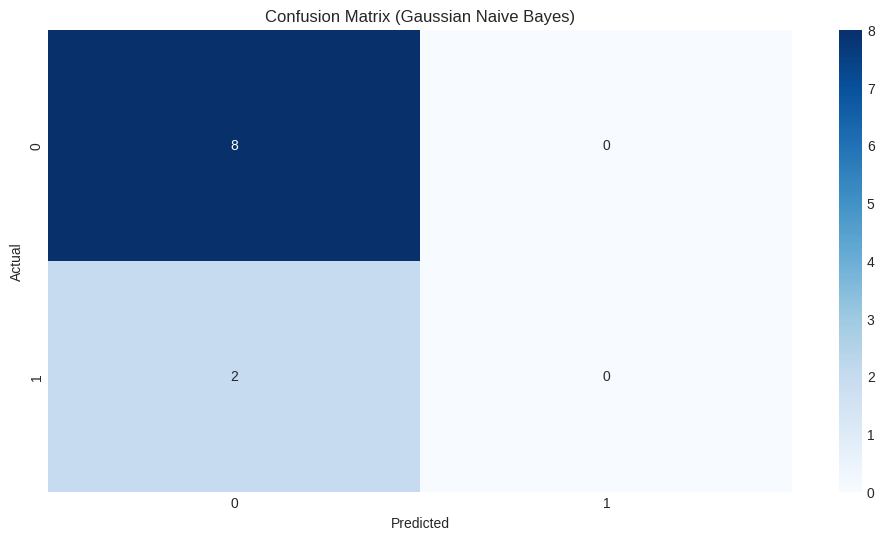

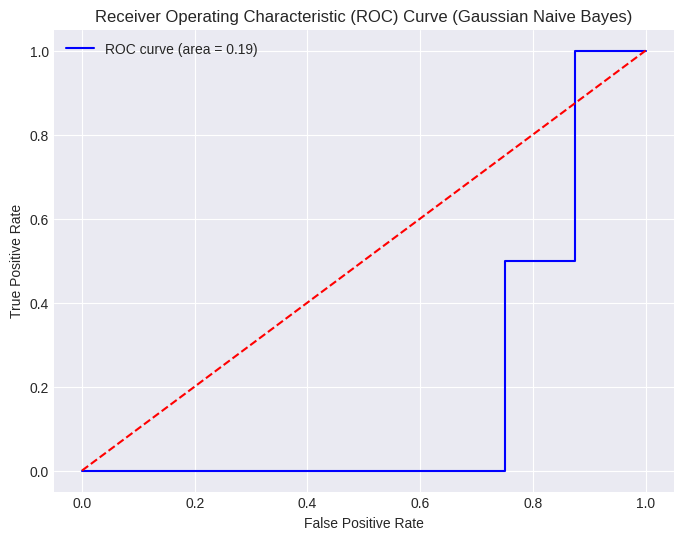

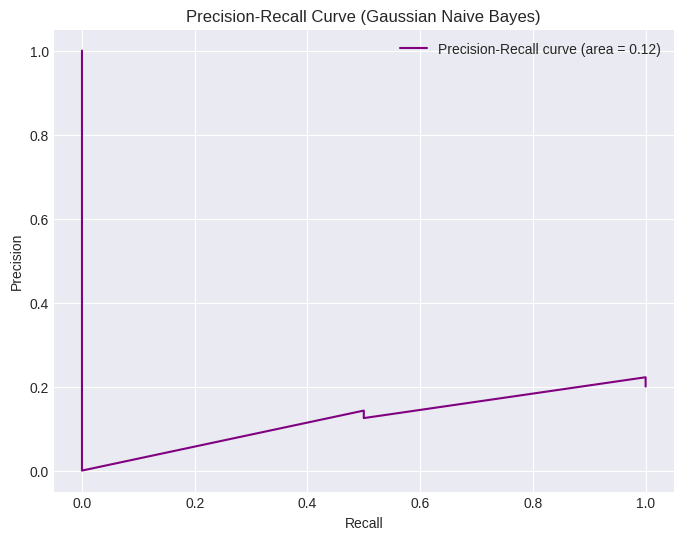


Insights from Gaussian Naive Bayes for Anomaly Prediction
The Gaussian Naive Bayes model's performance on the test set is as follows:
- ROC AUC: 0.19
- Precision-Recall AUC: 0.12
From the Classification Report, we can observe the precision, recall, and F1-score for both normal and anomaly classes.
The Confusion Matrix visually represents correct and incorrect predictions. The ROC and Precision-Recall curves provide further insights into the model's trade-offs between different metrics.


In [50]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*70)
print("Gaussian Naive Bayes Model for Future Anomaly Detection (RQ3)")
print("="*70)

# --- 1. Model Training (Gaussian Naive Bayes) --- #
gnb_model = GaussianNB()
gnb_model.fit(X_train_anomaly, y_train_anomaly)
print("Gaussian Naive Bayes Model trained successfully.")

# --- 2. Make Predictions on Test Data --- #
y_pred_gnb = gnb_model.predict(X_test_anomaly)
y_pred_proba_gnb = gnb_model.predict_proba(X_test_anomaly)[:, 1] # Probability of the positive class (anomaly = 1)

# --- 3. Evaluate Model --- #
print("\nClassification Report on Test Data (Gaussian Naive Bayes):")
print(classification_report(y_test_anomaly, y_pred_gnb))

# Calculate ROC AUC score
roc_auc_gnb = roc_auc_score(y_test_anomaly, y_pred_proba_gnb)
print(f"ROC AUC Score (Gaussian Naive Bayes): {roc_auc_gnb:.2f}")

# Confusion Matrix
print("\nConfusion Matrix (Gaussian Naive Bayes):")
cm_gnb = confusion_matrix(y_test_anomaly, y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Gaussian Naive Bayes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_gnb, tpr_gnb, thresholds_gnb = roc_curve(y_test_anomaly, y_pred_proba_gnb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, color='blue', label=f'ROC curve (area = {roc_auc_gnb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Gaussian Naive Bayes)')
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve (often more informative for imbalanced datasets)
precision_gnb, recall_gnb, _ = precision_recall_curve(y_test_anomaly, y_pred_proba_gnb)
pr_auc_gnb = auc(recall_gnb, precision_gnb)

plt.figure(figsize=(8, 6))
plt.plot(recall_gnb, precision_gnb, color='purple', label=f'Precision-Recall curve (area = {pr_auc_gnb:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Gaussian Naive Bayes)')
plt.legend()
plt.grid(True)
plt.show()

print("\n" + "="*70)
print("Insights from Gaussian Naive Bayes for Anomaly Prediction")
print("="*70)
print("The Gaussian Naive Bayes model's performance on the test set is as follows:")
print(f"- ROC AUC: {roc_auc_gnb:.2f}")
print(f"- Precision-Recall AUC: {pr_auc_gnb:.2f}")
print("From the Classification Report, we can observe the precision, recall, and F1-score for both normal and anomaly classes.")
print("The Confusion Matrix visually represents correct and incorrect predictions. The ROC and Precision-Recall curves provide further insights into the model's trade-offs between different metrics.")

### BSTS

You're interested in using a Bayesian Structural Time Series (BSTS) model for anomaly detection. That's an interesting approach! However, before we dive into implementing another model, let's reflect on the challenges we've consistently encountered across all our previous attempts, including Isolation Forest and Gaussian Naive Bayes.

We currently have an extremely small dataset, with only 32 data points overall, and a very limited number of actual anomalies in the test set (just 2). Do you recall how these data limitations have impacted the performance and reliability of the models we've tried so far for anomaly detection? What does that suggest about the likelihood of any model, even BSTS, providing robust and reliable predictions with the current data?